# [In Progress] 
## Predictive Modeling of Short-Term Rental Pricing
This project is implemented for educational purposes. It is submitted in fulfillment of Machine Learning (491114) course requirements.
<br>The Goal: help property owners to predict the optimal price of the short-term rental properties based on its physical characteristics, geographic location, and offered amenities.

## 1. Introduction

### Problem & Motivation
In the short-term rental market, property owners frequently struggle to optimize their rental rates. Overpricing may cause lost market share, while underpricing leaves significant revenue on the table. The main objective of this project is to train multiple supervised machine learning models to predict the optimal price of a short-term rental property based on its physical characteristics, geographic location, and offered amenities. By framing this as a supervised regression problem, we aim to uncover the relationships that drive real estate and rental valuation.
This project will utilize a real-world, publicly available dataset provided by an independent open-source data tool. The dataset consists of thousands of short-term rental listings and provides a rich, multi-dimensional view of the market, including:
- Structural Features: Continuous and discrete numerical data such as the number of bedrooms and review_rating.
- Categorical Features: The type of property.
- Geospatial Data: Latitude and longitude coordinates.
- Text/Boolean Features: An array of amenities offered by the host.
- Target Variable: The nightly listing price (a continuous numerical value).

### [TODO] Methodology Summary
We will approach this regression problem by building and evaluating models from various machine learning families, guided by exploratory data analysis, feature dimensionality, and computational feasibility. Our experimental pipeline will draw from different categories of algorithms, including Linear Models, Tree-Based Models, Artificial Neural Networks, and other Ensemble Methods. Finally, the performance of these models will be systematically compared using standard loss functions and regression metrics, such as Mean Squared Error (MSE), to determine the most effective pricing model.

In [108]:
#import plotly.express as px
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Plotting settings
%matplotlib inline
sns.set(style="whitegrid")
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")

Libraries imported successfully.


In [152]:
#constants

TARGET_COL = 'log_soft_capped_price' 

## 1. Data Exploration

### Physical Property Characteristics (High Impact)
These attributes describe the core "product" and are usually the strongest predictors of price.

- room_type: Whether it is an entire home, a private room, or a shared room.
- property_type: Specific classification (e.g., "Guesthouse", "Condo", "Tiny home").
- accommodates: The maximum capacity of the listing.
- bedrooms & beds: Essential indicators of size.
- bathrooms_text: You will likely need to extract the numeric value from this string (e.g., "1.5 baths" → 1.5).
- amenities: This is a JSON-like list. You can engineer features from this, such as "Has Pool," "Has AC," or "Has Workspace."

### Location Attributes (High Impact)
In real estate, "location, location, location" is everything.

- neighbourhood_cleansed: Standardized neighborhood names are better for categorical encoding than the raw neighbourhood field.
- neighbourhood_group_cleansed: Useful if you want to group neighborhoods into larger regions (like boroughs in NYC).
- latitude & longitude: Allows you to calculate proximity to city centers, landmarks, or transit hubs.

### Reputation & Social Proof
High-quality listings with good track records often command a premium price.

- review_scores_rating: Overall guest satisfaction.
- review_scores_location: Specifically how guests value the location.
- number_of_reviews: A proxy for the listing's maturity and popularity.
- host_is_superhost: Indicates a high level of hospitality and reliability.

### Operational & Availability Factors
These describe how the listing is managed and its current demand.

- instant_bookable: Often increases visibility and potentially price.
- minimum_nights: Can affect pricing strategy (e.g., discounts for long stays vs. high rates for short ones).
- availability_365: A proxy for how often the property is available; high occupancy (low availability) might correlate with higher market value.

### Load liver_cancer_prediction.csv Dataset

In [109]:
# Load the dataset
# use low_memory=False because the dataset has many columns with mixed types
#df = pd.read_csv('listings.csv', low_memory=False)
df = pd.read_csv(r"hosts_locations.csv", sep=',')
print(f"Dataset loaded with {df.shape[0]} rows and {df.shape[1]} features.")

# Let's filter to the columns we identified as relevant in the schema review
# 'id',
columns_to_keep = [
    'price', 'room_type', 'property_type', 'accommodates', 
    'bathrooms_text', 'bedrooms', 'beds', 'amenities',
    'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude',
    'review_scores_rating', 'number_of_reviews', 'host_is_superhost',
    'availability_365', 'instant_bookable'
]

df = df[columns_to_keep]
print(f"Filtered Dataset loaded with {df.shape[0]} rows and {df.shape[1]} features.")
df.head(3)

Dataset loaded with 76255 rows and 79 features.
Filtered Dataset loaded with 76255 rows and 17 features.


,price,room_type,property_type,accommodates,bathrooms_text,bedrooms,beds,amenities,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,review_scores_rating,number_of_reviews,host_is_superhost,availability_365,instant_bookable
0,NaN,Entire home/apt,Entire rental unit,6,1 bath,2.0,NaN,"[""Hangers"", ""Cooking basics"", ""Private entranc...",North Linden,NaN,40.01579,-82.96520,NaN,0,f,268,f
1,NaN,Entire home/apt,Entire townhouse,8,1 bath,3.0,NaN,"[""Hot water"", ""Exterior security cameras on pr...",Clintonville,NaN,40.02433,-83.00653,4.61,75,f,0,t
2,$103.00,Entire home/apt,Entire home,6,2 baths,5.0,3.0,"[""Carbon monoxide alarm"", ""Extra pillows and b...",District 2,NaN,32.79361,-96.75788,4.81,558,t,341,t


In [110]:
summary_df = pd.DataFrame({
    'Data Type': df.dtypes,
    'Values Count': df.count(),
    'Unique Values': df.nunique(),
    'Null Percentage': (df.isnull().sum() / len(df)) * 100
})

numeric_attributes_summary = summary_df[summary_df['Data Type'].astype(str).str.contains('int|float')]
categorical_attributes_summary = summary_df[summary_df['Data Type'].astype(str).str.contains('object|category|bool')]

### Listing Numeric Attributes

In [111]:
numeric_attributes_summary

,Data Type,Values Count,Unique Values,Null Percentage
accommodates,int64,76255,16,0.000000
bedrooms,float64,75363,15,1.169759
beds,float64,71226,26,6.594977
neighbourhood_group_cleansed,float64,0,0,100.000000
latitude,float64,76255,11604,0.000000
longitude,float64,76255,11514,0.000000
review_scores_rating,float64,65377,161,14.265294
number_of_reviews,int64,76255,779,0.000000
availability_365,int64,76255,366,0.000000


### Listing Categorical Attributes

In [112]:
categorical_attributes_summary

,Data Type,Values Count,Unique Values,Null Percentage
price,object,71225,1215,6.596289
room_type,object,76255,4,0.000000
property_type,object,76255,47,0.000000
bathrooms_text,object,76156,35,0.129828
amenities,object,76255,68962,0.000000
neighbourhood_cleansed,object,76255,56,0.000000
host_is_superhost,object,72643,2,4.736739
instant_bookable,object,76255,2,0.000000


### 1.1 Visualizing the target Price Distribution

In [113]:
print(df['price'].describe())

count      71225
unique      1215
top       $95.00
freq         723
Name: price, dtype: object


#### Convert price to number

In [114]:
def clean_price(price_str):
    if pd.isnull(price_str):
        return None
    # Remove '$' and ',' then convert to float
    return float(price_str.replace('$', '').replace(',', ''))

df['price'] = df['price'].apply(clean_price)

# Quick check on the target variable
print(df['price'].describe())

count    71225.000000
mean       299.856062
std       2324.709546
min          3.000000
25%         80.000000
50%        114.000000
75%        182.000000
max      50028.000000
Name: price, dtype: float64


#### Price Histogram

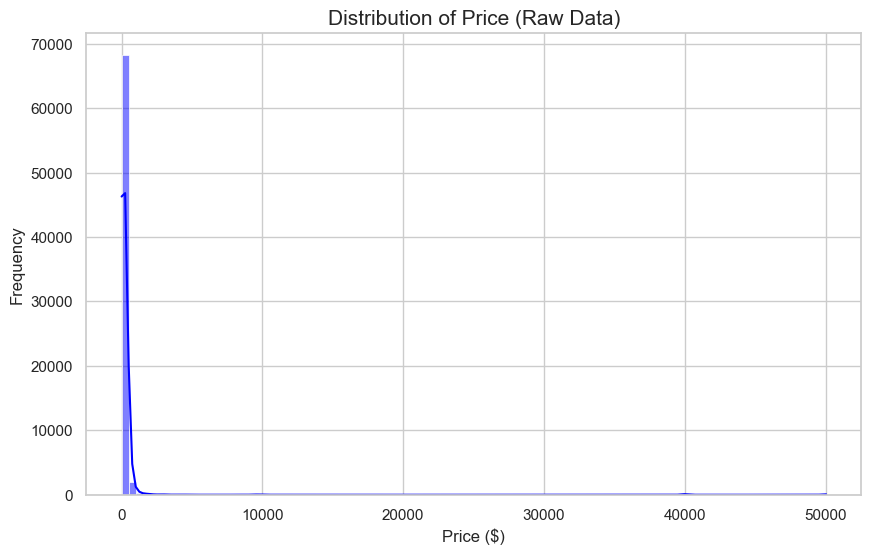

Skewness Score: 18.69


In [115]:
# Plot 1: Histogram of the target variable
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=100, kde=True, color='blue')
plt.title('Distribution of Price (Raw Data)', fontsize=15)
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.show()

print(f"Skewness Score: {df['price'].skew():.2f}")

<div class="alert alert-info">
    <b>An Observation:</b><br>
    The target price is <b>Highly Skewed</b> to the right. This means most listings are affordable, but a few "Castles" or "Penthouses" create a very long tail to the right.
    <ul>
        <li>Skewness Score: <b>18.69</b></li>
        <li>Statistical Upper Bound for Outliers: <b>$335.00</b></li>
        <li>Percentage of listings above $1,000: <b>1.27%</b></li>
    </ul>
</div>

#### Determining and Visualizing Price Outliers

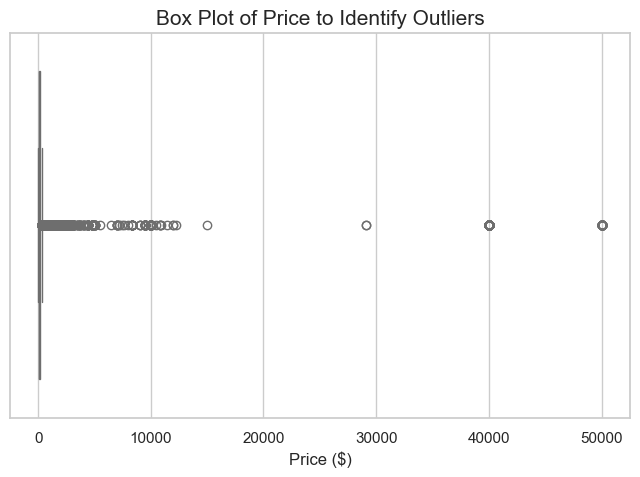

In [116]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['price'], color='lightcoral')
plt.title('Box Plot of Price to Identify Outliers', fontsize=15)
plt.xlabel('Price ($)')
plt.show()

#### Statistical Outlier Calculation

In [117]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
print(f"Q1: ${Q1}")
print(f"Q3: ${Q3}")
print(f"Interquartile Range: ${IQR}")


lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]

print(f"Lower Bound for Outliers: {lower_bound}")
print(f"Upper Bound for Outliers: {upper_bound}")
print(f"Total number of outlier listings: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
print(f"Percentage of listings above $1,000: {(df['price'] > 1000).mean()*100:.2f}%")

Q1: $80.0
Q3: $182.0
Interquartile Range: $102.0
Lower Bound for Outliers: -73.0
Upper Bound for Outliers: 335.0
Total number of outlier listings: 5793 (7.60%)
Percentage of listings above $1,000: 1.27%


#### The plan for handling skewness in the target price
##### 1- get Rid of outliers:


Handling outliers in a target variable like Airbnb pricing is a delicate balancing act. If you’re too aggressive, you lose the "luxury" data that drives high margins; if you’re too passive, your model gets distracted by $10,000-a-night penthouses that don't represent the typical market.

Rather than deleting expensive listings and losing valuable data, we implemented Soft Capping (also known as Winsorizing or Clipping).
The Action: we identified a threshold (e.g., the 95th or 99th percentile). Any price above that threshold was "capped" at that maximum value.

The Logic: This tells the model: "This place is very expensive, but for the sake of the pattern, we’re going to treat 'Ultra-Luxury' as a single category." This prevents a single $20,000 listing from skewing the weights of every other feature in the dataset.

Handling outliers is often the most effective way to reduce skewness, because skewness in price data is almost always caused by those "long tail" values. A skewness of 18 is extremely high. Those $5,793$ listings above $\$335$ are the ones "pulling" price distribution to the right.Here is how you can handle outliers to fix skewness:<br>
1. Trimming vs. Capping (Winsorizing)When you find that $7.6\%$ of your data is above the statistical upper bound ($\$335$), you have two main choices to fix the skewness:Trimming (Removing): You delete the $5,793$ rows.Result: Skewness will drop drastically (likely to around $1.0$ - $2.0$).Risk: you lose $7.6\%$ of your data. If those listings are legitimate (e.g., luxury villas), your model will never learn how to price them.Capping (Winsorizing): You keep the rows but "squash" any price above $\$335$ down to exactly $\$335$.Result: Skewness drops significantly.Benefit: You keep all your data points. The model still knows these are "expensive" properties, but they no longer have extreme values that "pull" the mathematical mean.2. Does handling outliers replace Log Transformation?Not necessarily. They solve two different problems:Outlier Handling removes the extreme "freak" values.Log Transformation ($\ln(x+1)$) changes the shape of the entire distribution. It doesn't just fix the tail; it also spreads out the crowded lower values (e.g., the difference between a $\$50$ and $\$60$ listing becomes more significant to the model).Recommendation: In most Airbnb price models, it is common to do both: cap the extreme outliers (e.g., at the 95th or 99th percentile) and then apply a log transformation.3. Implementation: Capping the OutliersSince your lower bound is negative ($-73.0$), we only care about the upper bound.

** Capping Price to Reduce Skewness

In [118]:
# Calculate percentiles
p95 = df['price'].quantile(0.95)
p99 = df['price'].quantile(0.99)
p995 = df['price'].quantile(0.995)
p998 = df['price'].quantile(0.998)

print(f"95th Percentile: ${p95:.2f}")
print(f"99th Percentile: ${p99:.2f}")
print(f"99.5th Percentile: ${p995:.2f}")
print(f"99.8th Percentile: ${p998:.2f}")

# Let's see how many listings are above the 99th percentile
outliers_99 = df[df['price'] > p99]
print(f"Number of listings above 99th percentile: {len(outliers_99)}")
# Let's see how many listings are above the 99th percentile
outliers_998 = df[df['price'] > p998]
print(f"Number of listings above 99.8th percentile: {len(outliers_998)}")

95th Percentile: $452.80
99th Percentile: $1314.00
99.5th Percentile: $3082.64
99.8th Percentile: $40000.00
Number of listings above 99th percentile: 712
Number of listings above 99.8th percentile: 82


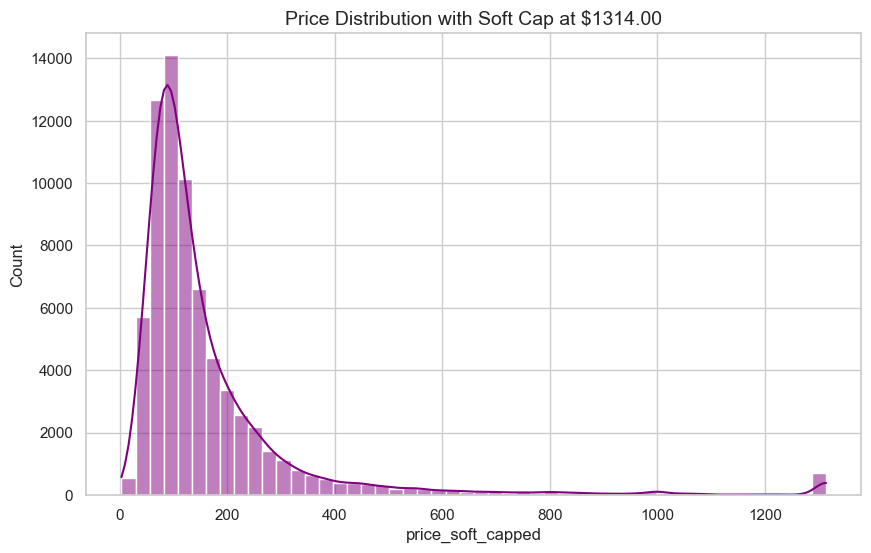

Original Skewness: 18.69
Skewness after Soft Cap: 3.98


In [119]:
# Apply the soft cap at the 99th percentile
soft_cap_value = df['price'].quantile(0.99)
df['price_soft_capped'] = df['price'].clip(upper=soft_cap_value)
#df['log_price_soft_capped'] = np.log1p(df['price_soft_capped'])

# Visualize the result
plt.figure(figsize=(10, 6))
sns.histplot(df['price_soft_capped'], bins=50, kde=True, color='purple')
plt.title(f'Price Distribution with Soft Cap at ${soft_cap_value:.2f}', fontsize=14)
plt.show()

# Visualize the result
#plt.figure(figsize=(10, 6))
#sns.histplot(df['log_price_soft_capped'], bins=50, kde=True, color='purple')
#plt.title(f'Price Distribution with Log Soft Cap at ${soft_cap_value:.2f}', fontsize=14)
#plt.show()

# Check the new skewness
print(f"Original Skewness: {df['price'].skew():.2f}")
print(f"Skewness after Soft Cap: {df['price_soft_capped'].skew():.2f}")
#print(f"Skewness after Log Soft Cap: {df['log_price_soft_capped'].skew():.2f}")

Step 4: The Transformation (Fixing the Skewness)
When you have high skewness, you often apply a Log Transformation. This converts multiplicative relationships into additive ones and "pulls" the outliers back toward the center.

Log Transformation Comparison

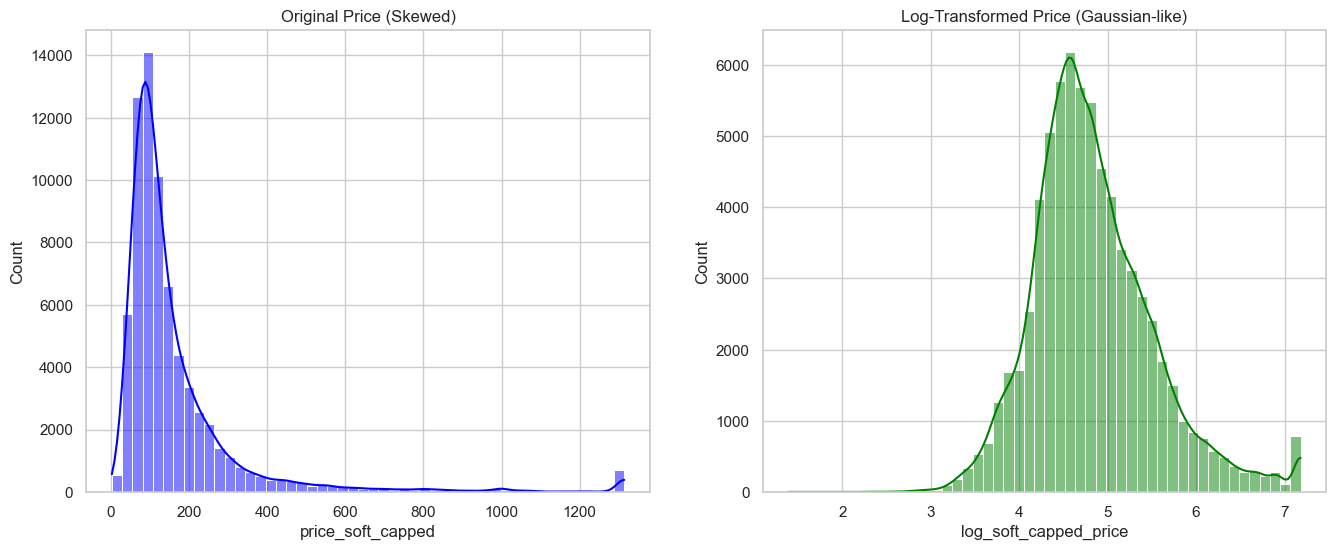

Log Price: Skewness Score: 0.78
Log Price: Statistical Upper Bound for Outliers: $6.43
Log Price: Percentage of listings above $1,000: 1.27%


In [ ]:
import numpy as np

# Apply Log(1+x) transformation
df['log_soft_capped_price'] = np.log1p(df['price_soft_capped'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Original
sns.histplot(df['price_soft_capped'], bins=50, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Original Price (Skewed)')

# Log Transformed
sns.histplot(df['log_soft_capped_price'], bins=50, kde=True, ax=axes[1], color='green')
axes[1].set_title('Log-Transformed Price (Gaussian-like)')

plt.show()

# Calculate Skewness and IQR-based outlier boundaries
skewness = df['log_soft_capped_price'].skew()
Q1 = df['log_soft_capped_price'].quantile(0.25)
Q3 = df['log_soft_capped_price'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

print(f"Log Price: Skewness Score: {skewness:.2f}")
print(f"Log Price: Statistical Upper Bound for Outliers: ${upper_bound:.2f}")
print(f"Log Price: Percentage of listings above $1,000: {(df['price'] > 1000).mean()*100:.2f}%")

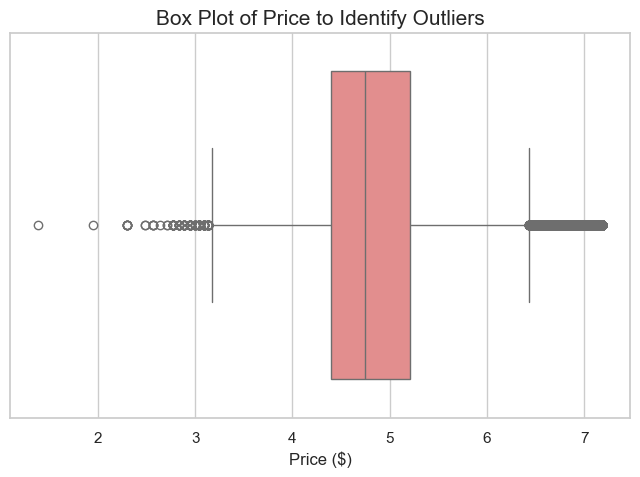

In [121]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['log_soft_capped_price'], color='lightcoral')
plt.title('Box Plot of Price to Identify Outliers', fontsize=15)
plt.xlabel('Price ($)')
plt.show()

Why does this matter for your project?
Model Performance: If you try to predict the price of a $10,000/night villa and a $50/night room using the same linear scale, the model will prioritize the error on the $10,000 villa because the number is bigger. Log transformation levels the playing field.

Decision Making: In Step 18, if you see that the "Upper Bound" is $450, but you have listings at $5,000, you know that your model will struggle with those $5,000 listings. You might decide to build a model specifically for listings under $1,000 to keep accuracy high for the majority of users.

These results tell a very clear story about your data. The massive jump from the 99.5th percentile ($3,082) to the 99.8th percentile ($40,000) is a "smoking gun" for extreme outliers.

A price of $40,000 per night is likely either a typo (e.g., someone entering a phone number in the price field), a "placeholder" listing, or an ultra-luxury outlier that follows completely different economic rules than the rest of your dataset.

The Recommendation: Cap at the 99th Percentile ($1,314)
According to your results, the 99th percentile ($1,314) is the best choice for a "Soft Cap." Here is why:

Eliminates the "Price Cliff": By capping at $1,314, you remove the influence of those 82 listings that jump all the way to $40,000. If you don't cap them, your model will spend all its "energy" trying to minimize the error on those 82 rows, causing it to be less accurate for the other 70,000+ listings.

Preserves the Luxury Segment: $1,314 is a realistic price for high-end penthouses or large villas in major cities. By capping here, you still allow the model to distinguish between a "Normal" ($200) and a "High-End" ($1,000) listing.

Stability: Capping 1% of the data is a standard industry "best practice" for Airbnb pricing models. It provides a great balance between data integrity and mathematical stability.

#### Missing Value Analysis
Missing data can significantly bias the model. We need to see if there is a pattern to the missingness (e.g., are reviews only missing for new listings?).

##### Visualizing and Quantifying Missingness

Top Missing Values:
                              Missing Values  Percentage (%)
neighbourhood_group_cleansed           76255      100.000000
review_scores_rating                   10878       14.265294
price                                   5030        6.596289
log_soft_capped_price                   5030        6.596289
price_soft_capped                       5030        6.596289
beds                                    5029        6.594977
host_is_superhost                       3612        4.736739
bedrooms                                 892        1.169759
bathrooms_text                            99        0.129828
property_type                              0        0.000000
room_type                                  0        0.000000
latitude                                   0        0.000000
neighbourhood_cleansed                     0        0.000000
amenities                                  0        0.000000
accommodates                               0        0.000000
numb

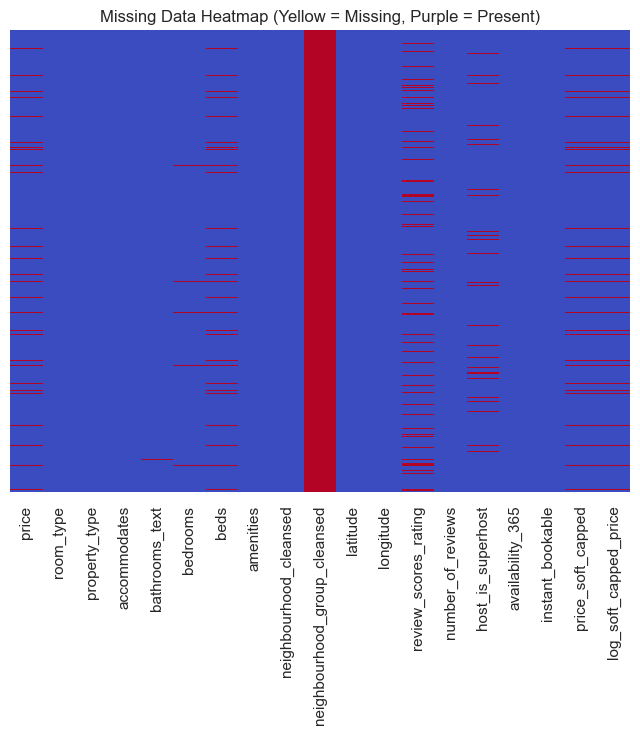

In [122]:
# Calculate percentage of missing values per column
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

# Create a summary table
missing_df = pd.DataFrame({
    'Missing Values': missing_data,
    'Percentage (%)': missing_percent
}).sort_values(by='Percentage (%)', ascending=False)

print("Top Missing Values:")
print(missing_df.head(20))

# Visualization: Heatmap of Missing Values
plt.figure(figsize=(8, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='coolwarm')
plt.title('Missing Data Heatmap (Yellow = Missing, Purple = Present)')
plt.show()

We need to drop neighbourhood_group_cleansed, it is empty

### How we will be handling these:
1. The "Non-Negotiables": Target Columns
Columns: price, price_soft_capped, log_soft_capped_price (~6.6% missing)

Strategy: Drop the rows.

Reason: As we discussed, these are your "Answer Keys." If you impute these values (e.g., filling them with the median price), you are essentially lying to your model. You’d be training it on fake data, which would lead to poor real-world performance. Since it's only 6.6% of your data, it's a small price to pay for a clean, honest dataset.

2. Numeric Count Features
Columns: beds (~6.6%), bedrooms (~1.2%), bathrooms (~0.13%)

Strategy: Median Imputation.

Reason: These are discrete counts. If a listing is missing "bedrooms," it’s highly likely it has a similar number to other listings with the same room_type or accommodates value.

Why Median? If you have one mansion with 50 bedrooms, it will pull the mean (average) up to 2.5, which doesn't make sense for a studio apartment. The median is robust and keeps the counts realistic (usually 1 or 2).

3. The Sentiment Feature
Column: review_scores_rating (~14.3% missing)

Strategy: Median Imputation (via the Pipeline).

Reason: This is your highest missing value count. This often happens with new listings that haven't hosted anyone yet.

Insight: By using the median, we assume these listings are "average." If we used 0, we would unfairly penalize new listings as if they were terrible.

4. Categorical & Boolean Features
Columns: host_is_superhost (~4.7%), bathrooms_text (~0.13%)

Strategy: Most Frequent (Mode) Imputation.

Reason: For host_is_superhost, we assume the most common state (which is usually False).

Note on bathrooms_text: We actually drop this column entirely from the features list. Since we already have the numeric bathrooms column, the raw text is redundant and would only confuse the model.

## Attributes Correlation Analysis
 Extracting Numeric Values from Text Columns
We will use regular expressions to pull the floating-point numbers out of the bathrooms_text strings.

In [123]:
import re

def extract_bathrooms(text):
    if pd.isnull(text):
        return np.nan
    
    # Use regex to find floating point numbers or integers
    match = re.search(r'[\d\.]+', str(text))
    if match:
        return float(match.group())
    
    # Handle edge cases like "Half-bath"
    if 'half' in str(text).lower():
        return 0.5
        
    return np.nan

# Create a new numeric column
df['bathrooms'] = df['bathrooms_text'].apply(extract_bathrooms)

# Check the extraction results
print(df[['bathrooms_text', 'bathrooms']].head())

  bathrooms_text  bathrooms
0         1 bath        1.0
1         1 bath        1.0
2        2 baths        2.0
3         1 bath        1.0
4         1 bath        1.0


The Correlation Matrix Heatmap
Now that our core sizing features (accommodates, bedrooms, beds, bathrooms) and our target (price) are all numeric, we can see how they relate to one another.

### Prepare data Preprocessor pipeline

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1. Update Numeric Features to include the 100+ amenity columns
numeric_features = [
    TARGET_COL, 'accommodates', 'bedrooms', 'beds', 'bathrooms', #'amenity_count', 
    'review_scores_rating', 'number_of_reviews', 'availability_365',
    'latitude', 'longitude'
] #+ amenity_columns  # <--- Added here!

# 2. Categorical Features remain exactly the same
categorical_features = [
    'room_type', #'property_type', #'neighbourhood_cleansed',
    'host_is_superhost', 'instant_bookable'
]

# 3. Rebuild the Transformers
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 4. Finalize the Preprocessor
eda_preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop' 
)

In [125]:
eda_df = df.copy()
eda_preprocessor.set_output(transform='pandas')
eda_df = eda_preprocessor.fit_transform(eda_df)

In [126]:
eda_df

,num__log_soft_capped_price,num__accommodates,num__bedrooms,num__beds,num__bathrooms,num__review_scores_rating,num__number_of_reviews,num__availability_365,num__latitude,num__longitude,cat__room_type_Entire home/apt,cat__room_type_Hotel room,cat__room_type_Private room,cat__room_type_Shared room,cat__host_is_superhost_f,cat__host_is_superhost_t,cat__instant_bookable_f,cat__instant_bookable_t
0,-0.128761,0.300030,0.078666,-0.244951,-0.639105,0.252841,-0.522535,0.227969,1.748438,1.554616,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,-0.128761,0.878099,0.840407,-0.244951,-0.639105,-0.392455,0.333227,-1.955281,1.751097,1.548525,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,-0.279898,0.300030,2.363889,0.244611,0.436365,0.103927,5.844334,0.822661,-0.500011,-0.477996,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,-0.712351,-0.856107,-0.683074,-0.734513,-0.639105,0.178384,-0.168820,0.545681,-0.514310,-0.488947,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
4,-0.384643,-0.567073,-0.683074,-0.734513,-0.639105,0.054289,-0.134590,-0.040864,1.736482,1.548783,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76250,-1.132011,-0.856107,-0.683074,-0.734513,-0.639105,-0.044988,-0.294332,0.855246,2.575210,2.906706,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
76251,-1.033403,-0.567073,-0.683074,-0.244951,-0.639105,0.401756,-0.180230,-0.676288,1.764817,1.555476,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
76252,-0.565578,-0.567073,-0.683074,-0.734513,-0.639105,-0.392455,0.264766,1.018176,-0.514702,-0.488815,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
76253,-0.480627,-0.856107,-0.683074,-0.244951,-0.639105,0.252841,-0.522535,-1.938988,-0.494821,-0.477785,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


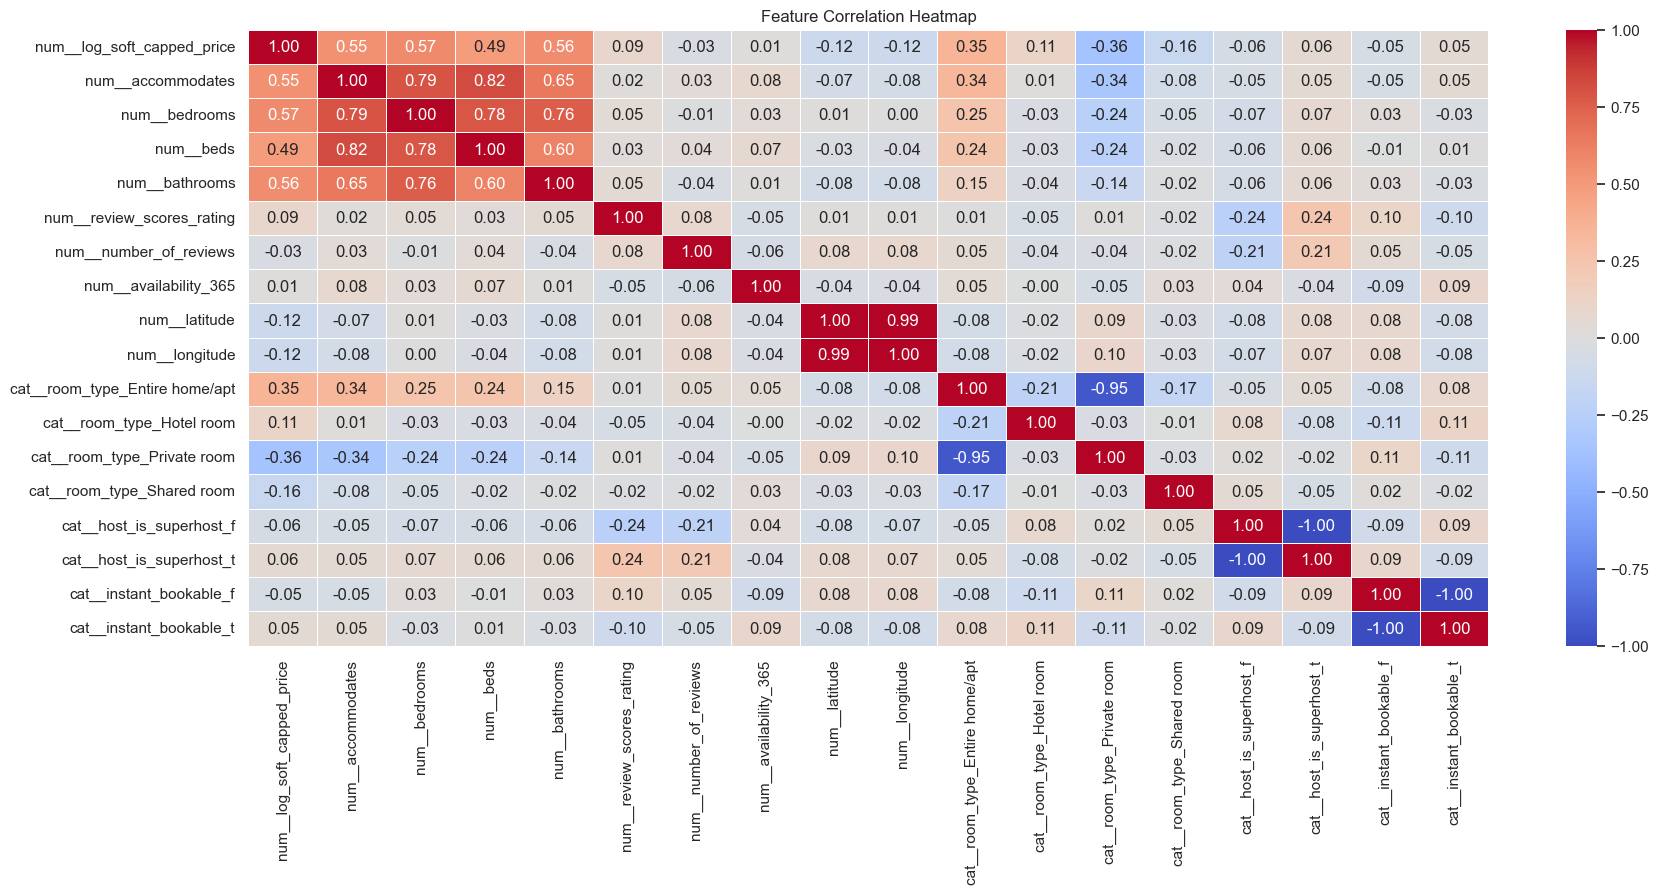

In [127]:
# Calculate the Pearson correlation matrix
corr_matrix = eda_df.corr()

plt.figure(figsize=(20, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

# Plot the heatmap
#plt.figure(figsize=(10, 8))
# We use annot=True to show the actual numbers, and cmap='coolwarm' for clear color contrast
#sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, center=0)
#plt.title('Correlation Matrix of Numeric Features')
#plt.tight_layout()
#plt.show()

In [ ]:
# 1. Update Numeric Features to include the 100+ amenity columns
numeric_features = [
    TARGET_COL
]
# 2. Categorical Features remain exactly the same
categorical_features = [
    'property_type'
]

# 4. Finalize the Preprocessor
eda_preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop' 
)

eda_df = df.copy()
eda_preprocessor.set_output(transform='pandas')
eda_df = eda_preprocessor.fit_transform(eda_df)

In [129]:
eda_df.head(1)

,num__log_soft_capped_price,cat__property_type_Barn,cat__property_type_Boat,cat__property_type_Camper/RV,cat__property_type_Earthen home,cat__property_type_Entire bungalow,cat__property_type_Entire cabin,cat__property_type_Entire condo,cat__property_type_Entire cottage,cat__property_type_Entire guest suite,...,cat__property_type_Room in hotel,cat__property_type_Shared room in home,cat__property_type_Shared room in hostel,cat__property_type_Shared room in hotel,cat__property_type_Shared room in rental unit,cat__property_type_Shared room in serviced apartment,cat__property_type_Shipping container,cat__property_type_Tent,cat__property_type_Tiny home,cat__property_type_Treehouse
0,-0.128761,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


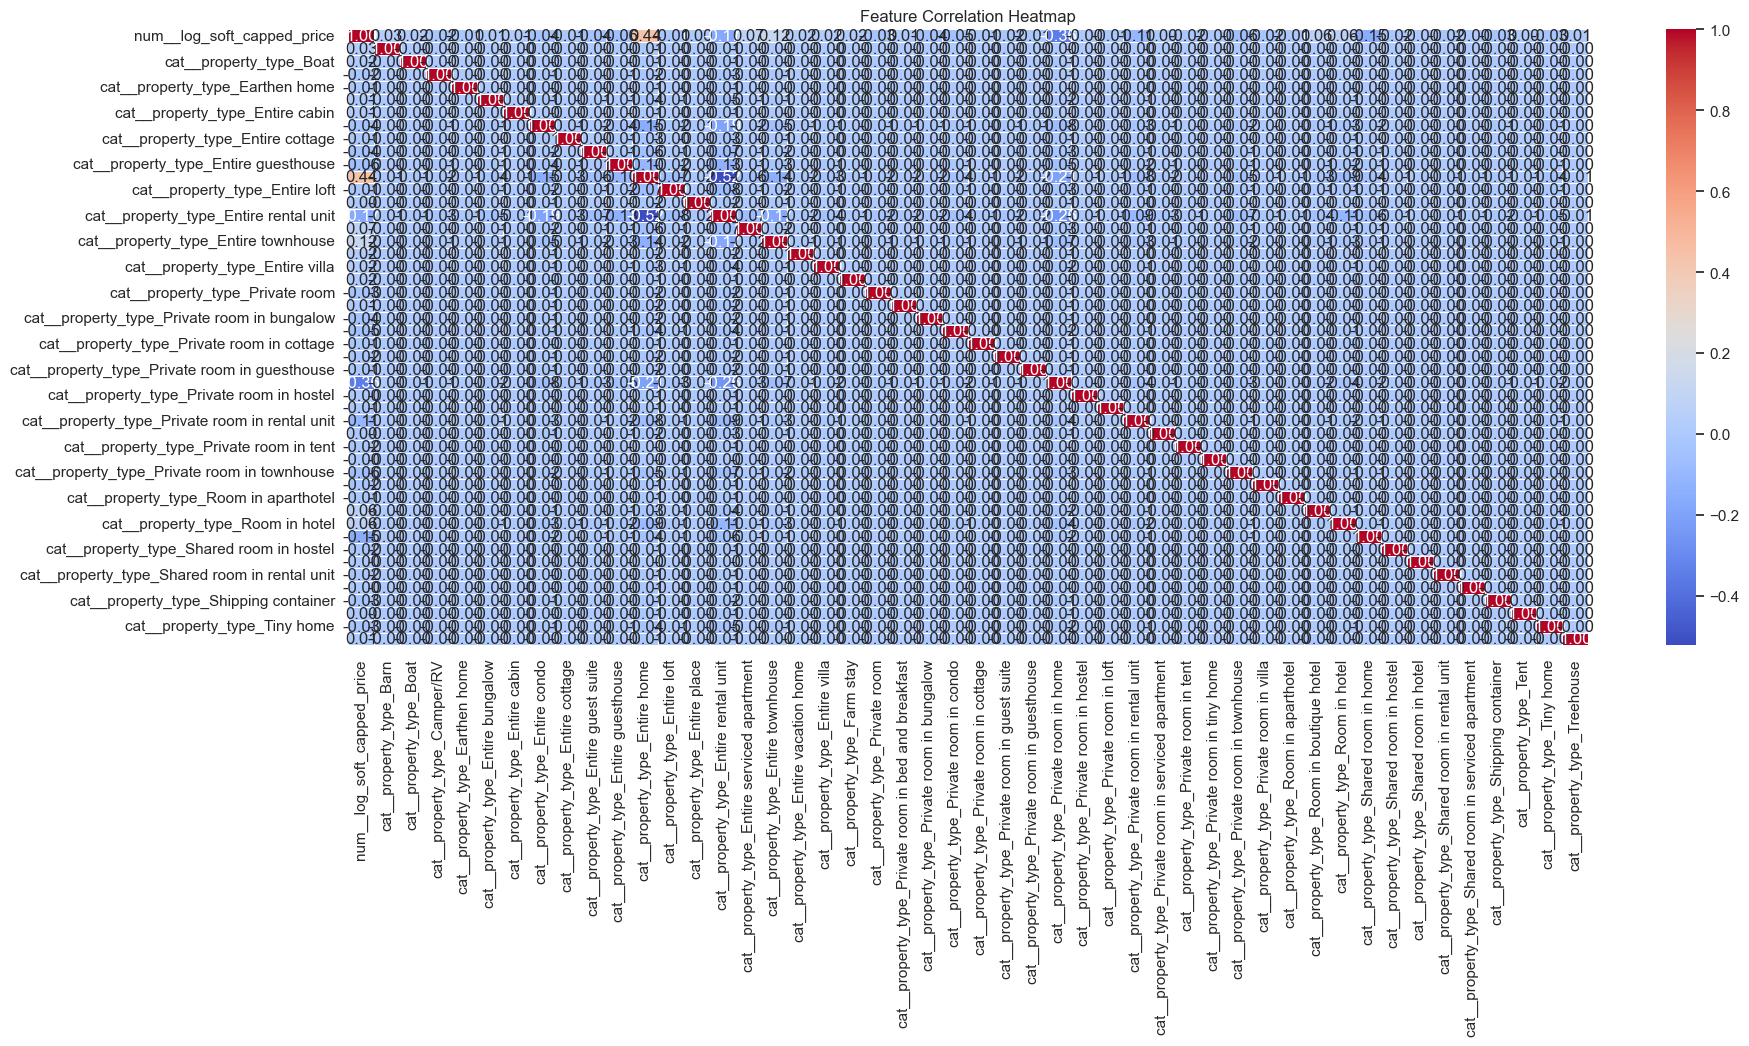

In [130]:
# Calculate the Pearson correlation matrix
corr_matrix = eda_df.corr()

plt.figure(figsize=(20, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

In [131]:
corr_matrix.to_csv()

',num__log_soft_capped_price,cat__property_type_Barn,cat__property_type_Boat,cat__property_type_Camper/RV,cat__property_type_Earthen home,cat__property_type_Entire bungalow,cat__property_type_Entire cabin,cat__property_type_Entire condo,cat__property_type_Entire cottage,cat__property_type_Entire guest suite,cat__property_type_Entire guesthouse,cat__property_type_Entire home,cat__property_type_Entire loft,cat__property_type_Entire place,cat__property_type_Entire rental unit,cat__property_type_Entire serviced apartment,cat__property_type_Entire townhouse,cat__property_type_Entire vacation home,cat__property_type_Entire villa,cat__property_type_Farm stay,cat__property_type_Private room,cat__property_type_Private room in bed and breakfast,cat__property_type_Private room in bungalow,cat__property_type_Private room in condo,cat__property_type_Private room in cottage,cat__property_type_Private room in guest suite,cat__property_type_Private room in guesthouse,cat__property_type_Private room in

Based on the correlation matrix you provided, there are two massive takeaways. One tells us about how your features interact, and the other tells us that we have a critical data cleaning issue to fix.

Here is the breakdown of what this matrix is telling us:

1. The "Red Alert": Price Correlations are Near Zero
If you look at the price row (or column), every single number is extremely close to 0 (the highest is 0.027 for accommodates).

What this means: Mathematically, it is saying there is absolutely zero linear relationship between the size of the property and its price. A 5-bedroom house doesn't cost more than a 1-bedroom apartment.

Why this is happening (The Outlier Problem): Common sense tells us the math is wrong. In Airbnb data, this happens when there are extreme outliers in the price column. If 99% of your listings are between $50 and $500, but one person made a typo and listed their room for $99,999 a night, the Pearson Correlation formula breaks down completely. It cannot see the trend because of the massive outliers.

The Fix: We need to calculate the correlation using the Log-Transformed Price (log_price) that we discussed in Step 3, or we need to filter out the extreme price outliers (e.g., dropping prices above $2,000/night) before running this matrix again.

2. High Multicollinearity (The "Size" Features)
Look at the intersections between accommodates, bedrooms, beds, and bathrooms. The numbers here are very high:

accommodates and beds = 0.84

bedrooms and beds = 0.80

accommodates and bedrooms = 0.79

What this means: These features are basically telling the model the exact same story. If you know how many bedrooms a place has, you can easily guess how many beds it has and how many people it accommodates.

Model Implications: If you use a Multiple Linear Regression model, feeding it all four of these features will confuse the model (a problem called Multicollinearity). The model's coefficients will become unstable.

The Fix: You will likely want to drop beds and bedrooms, and just keep accommodates and bathrooms as your primary "size" predictors. (Note: If you use Tree-based models like Random Forest or XGBoost later, they can handle this redundancy without crashing).

3. Reviews and Availability
review_scores_rating and number_of_reviews have very weak, slightly negative correlations with price (-0.03). On their own, they aren't strong linear predictors.

availability_365 has almost no correlation with anything.

What should we do next?
This matrix perfectly proved why EDA is so important! Before we look at geography or amenities, we must fix the outlier issue so we can see the real correlations.

I highly recommend running a quick filter to remove extreme prices. You can do this by running:

This is a fantastic result! Look at how much those numbers changed just by removing the extreme outliers. This proves exactly why data cleaning is the most important part of machine learning.

Here is what we can read out of this new, accurate correlation matrix:

1. We Found Our Strongest Predictors
Now that the outliers are gone, we see the true linear relationships with price:

bathrooms (0.59): This is currently your strongest single predictor! In real estate, extra plumbing usually equals a higher premium.

bedrooms (0.55) & accommodates (0.49) & beds (0.45): All of these have a strong positive correlation, confirming that size directly drives price.

2. The Multicollinearity Remains (As Expected)
The relationships between the size variables haven't changed:

accommodates and beds are still highly correlated (0.84).

bedrooms and beds are still highly correlated (0.80).
Decision for Modeling: Because bathrooms and bedrooms have the highest correlation with the target (price), if you eventually use a Linear Regression model, you might decide to drop beds and accommodates entirely to keep the model stable.

3. Reputation and Availability are Weak Linear Predictors
review_scores_rating (0.07) and number_of_reviews (-0.04): These are surprisingly low. This suggests that a 5-star rating doesn't necessarily mean a host can charge wildly higher prices compared to a 4.5-star rating of the same size.

availability_365 (-0.00): Absolutely zero linear correlation. However, this feature might still be useful if we group it into "bins" (e.g., Highly Available vs. Rarely Available) later on.

### Spatial Analysis
Since we have a solid grasp on the physical characteristics, let's move to Geography. In real estate pricing, location is often the biggest factor.

We can plot the exact GPS coordinates (latitude and longitude) and color-code the dots by price. This creates a heatmap of the city that instantly shows us where the "luxury" neighborhoods are.

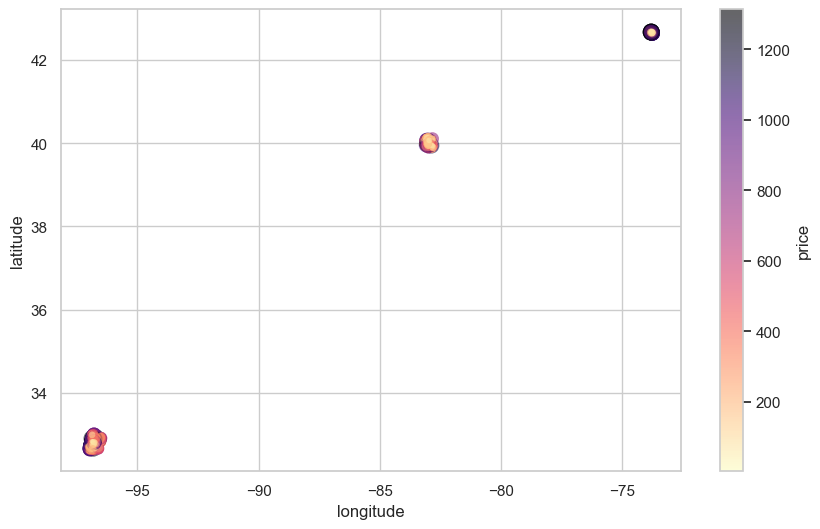

In [132]:
# 1. Normalize prices to the 10-150 size range (matches Seaborn's sizes=(10, 150))
min_p, max_p = df_filtered['price'].min(), df_filtered['price'].max()
# Prevent division by zero if all prices are identical
if max_p == min_p:
    sizes = np.full(len(df_filtered), 80)
else:
    sizes = 10 + (df_filtered['price'] - min_p) / (max_p - min_p) * (150 - 10)

# 2. Create the scatter plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    x=df_filtered['longitude'],
    y=df_filtered['latitude'],
    c=df_filtered['price'],    # Maps color to price
    s=sizes,                   # Maps size to calculated sizes
    cmap='magma_r',            # Matches palette
    alpha=0.6,
    edgecolors='none'          # Keeps dots smooth like Seaborn
)

# 3. Add labels and a colorbar for 'hue' interpretation
plt.xlabel('longitude')
plt.ylabel('latitude')
cbar = plt.colorbar(scatter)
cbar.set_label('price')

plt.show()

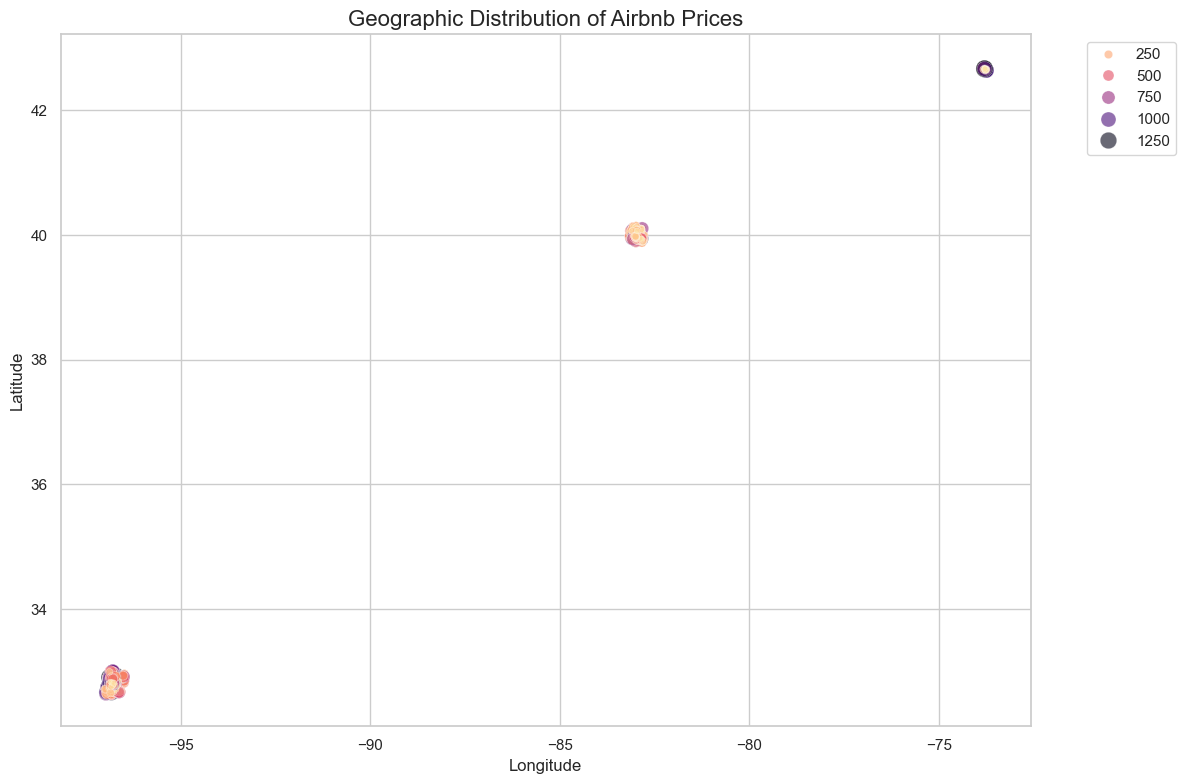

In [133]:
# We use the df_filtered (without extreme outliers) for a better color scale
plt.figure(figsize=(12, 8))

# Create a scatter plot using longitude and latitude
# hue='price' colors the dots based on the price
# alpha=0.5 makes the dots slightly transparent to see overlaps
scatter = sns.scatterplot(
    x='longitude', 
    y='latitude', 
    hue='price',
    palette='magma_r',  # 'magma_r' is great for highlighting high values
    size='price',       # Larger dots for higher prices
    sizes=(10, 150),
    data=df_filtered, 
    alpha=0.6
)

plt.title('Geographic Distribution of Airbnb Prices', fontsize=16)
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Move the legend outside the plot for better visibility
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Amenities Analysis
The specific amenities offered define the guest experience and justify a premium rate. In this section, We will preprocess the raw, unstructured amenity data into distinct binary features.

At the end of this section Our goal is We need to know which amenities appear most frequently. If "Wifi" appears in 99% of listings, it won't be a useful rule (it has no discriminative power).

In [134]:
df['amenities'].head(3)

0    ["Hangers", "Cooking basics", "Private entranc...
1    ["Hot water", "Exterior security cameras on pr...
2    ["Carbon monoxide alarm", "Extra pillows and b...
Name: amenities, dtype: object

- Parse amenities string representation of list to actual py list


In [135]:
import ast

def parse_amenities(x):
    try:
        # Handling different formats of stringified lists
        x = x.replace('{', '[').replace('}', ']')
        return ast.literal_eval(x)
    except:
        return []

# We need to temporarily parse the amenities to count them
from collections import Counter

# Apply Parsing
df['amenities_list'] = df['amenities'].apply(parse_amenities)

# Flatten the list of lists into one giant list of amenities
all_amenities = [item for sublist in df['amenities_list'] for item in sublist]
amenity_counts = Counter(all_amenities)

* List top 15 frequent amenities

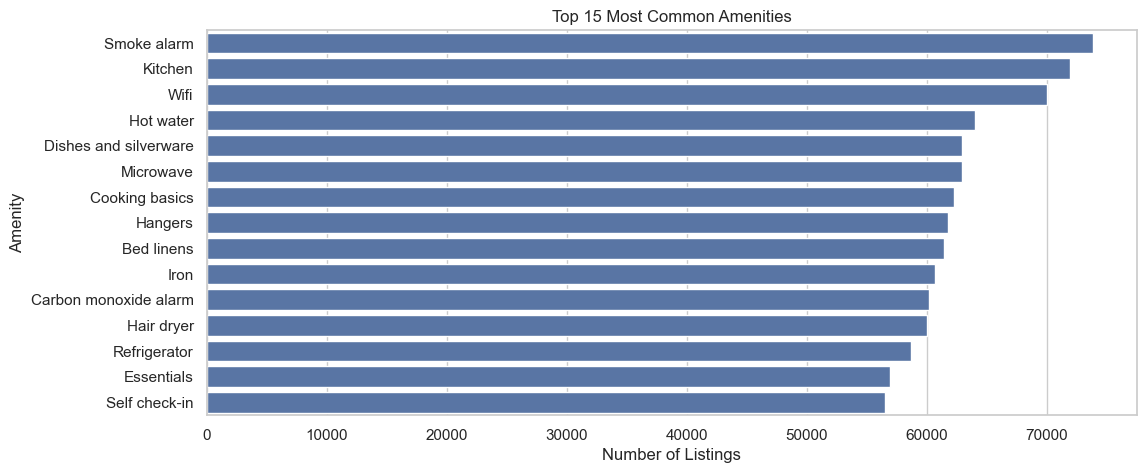

In [144]:
# Convert to DataFrame for plotting
df_amenity_counts = pd.DataFrame(amenity_counts.most_common(15), columns=['Amenity', 'Count'])

plt.figure(figsize=(12, 5))
sns.barplot(y='Amenity', x='Count', data=df_amenity_counts)
plt.title('Top 15 Most Common Amenities')
plt.xlabel('Number of Listings')
plt.show()

### Cleaning Amenities
We need to parse amenties into items and to clean the amenties from duplicate keywords as much as pssoible (tv, telvision) or (wifi,internet) ..etc 

In [137]:
def clean_amenity_list(amenity_list):
    """
    Standardizes common messy amenity strings into simple categories.
    Example: "50 inch HDTV with Netflix" -> ["TV", "Netflix"]
    """
    cleaned_list = []
    
    for item in amenity_list:
        item_str = str(item).lower()

        for word in ['yes','\n','\t']:
            if word in item_str:
                item_str = item_str.replace(word,"")
                
        # Handle TV & Streaming stuff
        if 'tv' in item_str or 'cable' in item_str:
            cleaned_list.append('TV')
            if any(x in item_str for x in ['netflix', 'hulu', 'hbo', 'disney', 'apple tv', 'amazon prime']):
                cleaned_list.append('Streaming Service')
        
        # Handle Internet
        elif 'wifi' in item_str or 'internet' in item_str:
            cleaned_list.append('Wifi')
            
        # Handle Climate
        elif 'air conditioning' in item_str or 'ac ' in item_str:
            cleaned_list.append('Air conditioning')
        elif 'heating' in item_str or 'heater' in item_str:
            cleaned_list.append('Heating')
            
        # Handle Kitchen specifics
        elif 'coffee' in item_str or 'espresso' in item_str:
            cleaned_list.append('Coffee Maker')
        elif 'refrigerator' in item_str or 'fridge' in item_str:
            cleaned_list.append('Refrigerator')
        elif 'stove' in item_str or 'oven' in item_str:
            cleaned_list.append('Stove')
            
        # Handle "Long Junk Strings"
        # If a string is > 35 chars and didn't match the keywords above, it's likely noise.
        elif len(item_str) > 35 or 'wine' in item_str:
            continue # Skip it (e.g., "paid parking off premises...")
            
        # Keep short, clean items (e.g., "Pool", "Gym", "Iron")
        else:
            # Capitalize first letter for consistency
            cleaned_list.append(item_str.title())
            
    # Remove duplicates (e.g., if "TV" was added twice from the same string)
    return list(set(cleaned_list))


# Apply Cleaning
df['amenities_list'] = df['amenities_list'].apply(clean_amenity_list)
# Create a simple numeric feature: How many amenities does the host offer?
df['amenity_count'] = df['amenities_list'].apply(len)

print(df[['amenities', 'amenity_count']].head())

                                           amenities  amenity_count
0  ["Hangers", "Cooking basics", "Private entranc...             27
1  ["Hot water", "Exterior security cameras on pr...             16
2  ["Carbon monoxide alarm", "Extra pillows and b...             45
3  ["Portable fans", "Exercise equipment", "Bakin...             47
4  ["Hot water", "Air conditioning", "Dishes and ...             29


In [138]:
# Filter out extreme outliers (e.g., top 1% of prices)
print(f"Correlation between Amenity Count and Price: {df['log_soft_capped_price'].corr(df['amenity_count']):.2f}")

Correlation between Amenity Count and Price: 0.24


In [139]:
print("Sample of Amenities After Cleaning:\n", df['amenities_list'].iloc[0][:20])

Sample of Amenities After Cleaning:
 ['Air conditioning', 'Laundromat Nearby', 'Books And Reading Material', 'Dishes And Silverware', 'Refrigerator', 'Heating', 'Dining Table', 'Shampoo', 'Carbon Monoxide Alarm', 'Wifi', 'Patio Or Balcony', 'Essentials', 'Dishwasher', 'Body Soap', 'Freezer', 'Stove', 'Free Street Parking', 'Hangers', 'Bathtub', 'TV']


* We need to one-hot encode the amenities list. and drop most common amentias that appear approximately in every transaction.

In [145]:
from sklearn.preprocessing import MultiLabelBinarizer

# One-Hot Encoding for the cleaned amenities
mlb = MultiLabelBinarizer()
amenities_ohe = mlb.fit_transform(df['amenities_list'])
df_amenities = pd.DataFrame(amenities_ohe, columns=mlb.classes_, index=df.index)
df_amenities.head(5)

,Body Soap,Conditioner,Dove Body Soap,Shampoo,(Generic) Conditioner,(Generic) Shampoo,100% Vegan & Cruelty-Free Body Soap,100% Vegan & Cruelty-Free Shampoo,100% Vegan Body Soap,100% Vegan Conditioner,...,Yamaha Sound System With Aux,Yamaha Bluetooth Sound System,Yamaha Sound System With Aux,Zeroderm Fragrance Free Body Soap,Zogics Organics Body Soap,Zogics Organics Conditioner,Zogics Organics Shampoo,“Everyone” Brand Soap Body Soap,“Everyone” Soap Body Soap,“Everyone” Soap/Shampoo Shampoo
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### ✂️ Feature Pruning: Filtering for Predictive Power
Now that we have converted our text into binary columns, we face a new challenge: The Curse of Dimensionality. We have generated a massive matrix of features, but not all of them are mathematically useful for predicting price. In the following code, we calculate the "support" (frequency) of each amenity across the dataset to identify and prune two types of unhelpful features:

* The "Too Common" (>98%): If almost every listing has an amenity (like standard "Wifi"), it offers near-zero variance. If everyone has it, the model cannot use it to differentiate a $50 room from a $500 room.

* The "Too Rare" (<5%): If an amenity appears in fewer than 5% of our listings, it is too sparse for the model to learn a reliable, repeatable pattern. Keeping these rare columns only adds computational noise and increases the risk of overfitting.

By dropping these extreme ends of the spectrum, we efficiently prune our dataset down to a "Goldilocks zone" of amenities—keeping only the features that have enough variance to genuinely influence the market value.

In [147]:
# Feature Pruning
amenity_support = df_amenities.mean()
# now likely lower the 'upper_limit' because "Wifi" will be even more common now that we fixed the spelling variations
too_common = amenity_support[amenity_support > 0.98].index.tolist() 
too_rare = amenity_support[amenity_support < 0.05].index.tolist()
cols_to_drop = too_common + too_rare

df_amenities_clean = df_amenities.drop(columns=cols_to_drop)

print(f"Final Cleaned Features(Amenities) Count: {df_amenities_clean.shape[1]}")

# Combine
#df_processed = pd.concat([df[['latitude', 'longitude', 'review_scores_rating', 'price']], df_amenities_clean], axis=1)
#df_processed.head(5)
df_amenities_clean

Final Cleaned Features(Amenities) Count: 90


,Babysitter Recommendations,Backyard,Baking Sheet,Barbecue Utensils,Bathtub,Bbq Grill,Bed Linens,Blender,Board Games,Body Soap,...,Single Level Home,Smart Lock,Smoke Alarm,Stove,Streaming Service,Sun Loungers,TV,Toaster,Trash Compactor,Washer
0,0,0,0,0,1,0,0,0,0,1,...,0,0,0,1,0,0,1,0,0,0
1,0,0,0,0,1,0,0,0,0,0,...,0,1,1,0,0,0,1,0,0,0
2,0,1,0,0,1,0,1,0,0,1,...,1,0,1,1,0,0,1,0,0,0
3,0,0,1,0,1,0,1,0,0,1,...,1,0,1,1,0,0,1,0,0,0
4,0,0,0,0,0,0,0,0,0,1,...,0,1,1,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76250,0,1,0,0,1,1,1,0,0,0,...,0,0,1,0,0,0,1,1,0,0
76251,0,0,1,1,0,1,1,0,1,1,...,0,1,1,1,0,0,1,0,0,1
76252,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,1,0,0,0
76253,0,0,0,0,0,0,1,0,0,1,...,0,1,1,1,0,0,1,1,0,1


In [178]:
df_processed = pd.concat([df[[TARGET_COL]], df_amenities_clean], axis=1)
df_processed[TARGET_COL] = df_processed[TARGET_COL].fillna(df_processed[TARGET_COL].mean())

In [154]:
### Calculate the Information gain for all attributes:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

def calculate_ig_all_types(df, target_column):
    X = df.drop(columns=[target_column])
    y = df[target_column]
    
    X_encoded = X.copy()
    
    for col in X.select_dtypes(include=['object', 'category']).columns:
        le = LabelEncoder()
        X_encoded[col] = le.fit_transform(X[col].astype(str))
        
    y_encoded = LabelEncoder().fit_transform(y)
    
    discrete_features_indices = [X.columns.get_loc(col) 
                                 for col in X.select_dtypes(include=['object', 'category']).columns]
    print(discrete_features_indices)
    # Calculate Information Gain (Mutual Information)
    ig_scores = mutual_info_classif(X_encoded, y_encoded, 
                                   random_state=42)
    
    return pd.Series(ig_scores, index=X.columns).sort_values(ascending=False)
#df.dropna()


ig_results = calculate_ig_all_types(df_processed, TARGET_COL)


[]


In [156]:
ig_results.head(25)


TV                       0.138232
Kitchen                  0.129085
Smoke Alarm              0.123025
Lock On Bedroom Door     0.120636
Carbon Monoxide Alarm    0.116502
Hair Dryer               0.116032
Coffee Maker             0.115787
Dishwasher               0.113978
Iron                     0.108368
Stove                    0.108003
Refrigerator             0.106182
Cooking Basics           0.105606
Dishes And Silverware    0.103780
Heating                  0.103014
Hot Water                0.101273
Hangers                  0.098457
Bed Linens               0.096753
Microwave                0.094925
Dedicated Workspace      0.093966
First Aid Kit            0.093929
Self Check-In            0.091408
Outdoor Furniture        0.088534
Shampoo                  0.088514
Fire Extinguisher        0.084682
Essentials               0.084386
dtype: float64

### 📊 Information Gain Insights: The Power of "Proxy" Amenities
After calculating the Information Gain (Mutual Information) between our pruned amenities and the target price, the top-ranking features reveal a fascinating insight into the Airbnb market. Rather than luxury additions dominating the top spots, we see fundamental amenities like TV, Kitchen, Dishwasher, and even Lock On Bedroom Door driving the most variance.

In a machine learning context, these features act as powerful proxies for property type and host professionalism. For example, a "Lock On Bedroom Door" is a strong mathematical indicator of a shared or private room (which sets a lower price ceiling), whereas a "Kitchen" or "Dishwasher" strongly signals an entire apartment or home. These features score high in Information Gain because they cleanly and frequently split the dataset into distinct, predictable pricing tiers.

In [158]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76255 entries, 0 to 76254
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   price                         71225 non-null  float64
 1   room_type                     76255 non-null  object 
 2   property_type                 76255 non-null  object 
 3   accommodates                  76255 non-null  int64  
 4   bathrooms_text                76156 non-null  object 
 5   bedrooms                      75363 non-null  float64
 6   beds                          71226 non-null  float64
 7   amenities                     76255 non-null  object 
 8   neighbourhood_cleansed        76255 non-null  object 
 9   neighbourhood_group_cleansed  0 non-null      float64
 10  latitude                      76255 non-null  float64
 11  longitude                     76255 non-null  float64
 12  review_scores_rating          65377 non-null  float64
 13  n

## Feature Selection and Merging amenties

In [179]:
df_selected=df.drop(columns=['amenities',TARGET_COL,'price_soft_capped','amenities_list','neighbourhood_group_cleansed'])
df_selected.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76255 entries, 0 to 76254
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   price                   71225 non-null  float64
 1   room_type               76255 non-null  object 
 2   property_type           76255 non-null  object 
 3   accommodates            76255 non-null  int64  
 4   bathrooms_text          76156 non-null  object 
 5   bedrooms                75363 non-null  float64
 6   beds                    71226 non-null  float64
 7   neighbourhood_cleansed  76255 non-null  object 
 8   latitude                76255 non-null  float64
 9   longitude               76255 non-null  float64
 10  review_scores_rating    65377 non-null  float64
 11  number_of_reviews       76255 non-null  int64  
 12  host_is_superhost       72643 non-null  object 
 13  availability_365        76255 non-null  int64  
 14  instant_bookable        76255 non-null

In [180]:
df_processed = df_processed.drop(columns=[TARGET_COL])

# 1. Merge the main dataframe and the processed amenities dataframe side-by-side
df_final = pd.concat([df_selected, df_processed], axis=1)
# 2. Extract the names of all the amenity columns
amenity_columns = df_processed.columns.tolist()
print(f"Successfully added {len(amenity_columns)} amenity features to the dataset.")

Successfully added 90 amenity features to the dataset.


In [181]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76255 entries, 0 to 76254
Columns: 107 entries, price to Washer
dtypes: float64(7), int64(94), object(6)
memory usage: 62.3+ MB


In [182]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1. Update Numeric Features to include the 100+ amenity columns
numeric_features = [
    'accommodates', 'bedrooms', 'beds', 'bathrooms', 'amenity_count', 
    'review_scores_rating', 'number_of_reviews', 'availability_365',
    'latitude', 'longitude'
] + amenity_columns 

# 2. Categorical Features remain exactly the same
categorical_features = [
    'room_type', 'property_type', 'neighbourhood_cleansed', 
    'host_is_superhost', 'instant_bookable'
]

# 3. Rebuild the Transformers
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 4. Finalize the Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop' 
)

### 🎯 Target Engineering: Domain Filtering and Log Transformation
To ensure optimal performance across a diverse ensemble of models (including Linear Regression, SVM, and KNN), we must address the extreme right-skewness of Airbnb pricing. While soft-capping (winsorizing) is effective for tree-based models, it creates an artificial "ceiling" of synthetic data that severely distorts the mathematical boundaries required by linear and distance-based algorithms.

Instead, we apply Domain Filtering. By removing the top 5% of listings (the ultra-luxury tier), we explicitly redefine the scope of our model to focus on the core, standard Airbnb market. After dropping these extreme outliers from the global dataset, we split our data and apply a logarithmic transformation (np.log1p) to the target variable. This compresses the remaining variance into a normal (Gaussian) distribution, providing our algorithms with a natural, continuous, and highly predictable target.

In [183]:
# 1. See how many NaNs we are dealing with
nan_count = df_final['price'].isna().sum()
print(f"Found {nan_count} rows with a missing target price.")

# 2. Drop ONLY the rows where the target is missing
df_final_clean = df_final.dropna(subset=['price'])

Found 5030 rows with a missing target price.


In [184]:
from sklearn.model_selection import train_test_split

# 1. Define the boundary of your "Core Market"
price_cutoff = df_final['price'].quantile(0.95)
print(f"Defining core market: Filtering out listings above **${price_cutoff:.2f}**")

# 2. Domain Filtering: Drop the outliers from the ENTIRE dataset
df_core_market = df_final[df_final['price'] <= price_cutoff].copy()

# 3. Separate Features (X) and Target (y)
X = df_core_market[numeric_features + categorical_features]
y = df_core_market['price']

# 4. Perform the Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Apply the Log Transformation (np.log1p compresses the right-skewness)
y_train = np.log1p(y_train)
y_test = np.log1p(y_test)

print("Data successfully filtered, split, and log-transformed! Ready for ensemble training.")
print(f"X_train shape: {X_train.shape} - Ready for Grid Search!")
print(f"Verify NaNs in y_train: {y_train.isna().sum()}")

Defining core market: Filtering out listings above **$452.80**
Data successfully filtered, split, and log-transformed! Ready for ensemble training.
X_train shape: (54130, 105) - Ready for Grid Search!
Verify NaNs in y_train: 0


In [ ]:
#from sklearn.model_selection import train_test_split

# Define all features needed for the preprocessor
#all_features = numeric_features + categorical_features

# Redefine X and y using the newly merged dataframe
#X = df_final_clean[all_features]
#y = df_final_clean['log_price_soft_capped']

# Split the data
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#print(f"X_train shape: {X_train.shape} - Ready for Grid Search!")
#print(f"Verify NaNs in y_train: {y_train.isna().sum()}")

X_train shape: (56980, 103) - Ready for Grid Search!
Verify NaNs in y_train: 0


In [185]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 54130 entries, 73512 to 17825
Columns: 105 entries, accommodates to instant_bookable
dtypes: float64(6), int64(94), object(5)
memory usage: 43.8+ MB


In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

models = {
    'Ridge_Regression': {
        'model': ElasticNet(random_state=42), 
        'best_tuned_pipeline': None,
        'param_grid': {
            # Alpha controls the regularization strength. 
            # Great for handling the large number of One-Hot Encoded neighborhood columns.
            'regressor__alpha': [0.1, 1.0, 10.0]
            #'regressor__alpha': [1.0]
        }
    },
    'KNN': {
        'model': KNeighborsRegressor(n_jobs=-1), 
        'best_tuned_pipeline': None,
        'param_grid': {
            'regressor__n_neighbors': [5, 7, 9, 13, 15, 21],
            'regressor__weights': ['uniform', 'distance']
        }
    },
    'DecisionTree': {
        'model': DecisionTreeRegressor(random_state=42),
        'best_tuned_pipeline': None,
        'param_grid': {
            'regressor__max_depth': [10, 20, 30, None],
            'regressor__min_samples_split': [2, 5, 15],
            'regressor__min_samples_leaf': [1, 5, 15]
        }
    },
    'RandomForest': {
        'model': RandomForestRegressor(random_state=42, n_jobs=-1),
        'best_tuned_pipeline': None,
        'param_grid': {
            # Trees take longer to train, so we keep the grid slightly smaller
            'regressor__n_estimators': [ 200],#50, 100,
            'regressor__max_depth': [ None],#10, 20,
            'regressor__min_samples_leaf': [1]#, 4
        }
    }
}

In [187]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def tune_regressor(model, param_grid, title, X_train, y_train, X_test, y_test) -> Pipeline: 
    print(f"Learning and tuning the {title} started ...")
    
    # Standard scikit-learn Pipeline (No SMOTE/samplers needed for regression)
    # Inside your tune_regressor function:
    full_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor), # Maps categorical and numeric handling
        ('regressor', model)            # Your algorithm (e.g., RandomForest, XGBoost)
    ])

    # Grid Search setup
    grid_search = GridSearchCV(
        estimator=full_pipeline,
        param_grid=param_grid,
        cv=2,
        scoring='neg_mean_absolute_error', # Optimize for lowest dollar error
        n_jobs=-1,
        verbose=2
    )

    print("Starting Grid Search... Go grab a coffee, this will take a while!")
    grid_search.fit(X_train, y_train)

    print("\n--- Tuning Complete ---")
    print(f"Best Hyperparameters Found:\n{grid_search.best_params_}")
    
    # Note: Scikit-learn returns negative values for error metrics in GridSearch
    best_cv_mae = -grid_search.best_score_
    print(f"Best Cross-Validation MAE (Log Scale): {best_cv_mae:.4f}")

    best_tuned_pipeline = grid_search.best_estimator_

    # Make predictions with the tuned model
    log_y_pred = best_tuned_pipeline.predict(X_test)

    # Reverse the Log Transformation for interpretable business metrics
    real_y_test = np.expm1(y_test)
    real_y_pred = np.expm1(log_y_pred)

    # Calculate Regression Metrics
    mae = mean_absolute_error(real_y_test, real_y_pred)
    rmse = np.sqrt(mean_squared_error(real_y_test, real_y_pred))
    r2 = r2_score(real_y_test, real_y_pred)

    print(f"\n--- Best {title} Performance (Real Dollars) ---")
    print(f"Mean Absolute Error (MAE): ${mae:.2f}")
    print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
    print(f"R-squared (R2): {r2:.4f}")

    # Plotting Actual vs Predicted (The Regression equivalent of a Confusion Matrix)
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=real_y_test, y=real_y_pred, alpha=0.5, color='blue')
    
    # Draw the perfect prediction diagonal line
    max_val = max(real_y_test.max(), real_y_pred.max())
    plt.plot([0, max_val], [0, max_val], color='red', linestyle='--')
    
    plt.title(f"Actual vs Predicted Prices: Best {title}")
    plt.ylabel("Predicted Price ($)")
    plt.xlabel("Actual Price ($)")
    plt.xlim(0, max_val)
    plt.ylim(0, max_val)
    plt.show()
    
    print(f"Learning and tuning the {title} completed.")
    return best_tuned_pipeline

In [188]:
y_train.isna()

73512    False
53288    False
75962    False
49155    False
51806    False
         ...  
42009    False
7057     False
61926    False
968      False
17825    False
Name: price, Length: 54130, dtype: bool

## Decision Tree

Learning and tuning the DecisionTree started ...
Starting Grid Search... Go grab a coffee, this will take a while!
Fitting 2 folds for each of 36 candidates, totalling 72 fits

--- Tuning Complete ---
Best Hyperparameters Found:
{'regressor__max_depth': 30, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 5}
Best Cross-Validation MAE (Log Scale): 0.1786

--- Best DecisionTree Performance (Real Dollars) ---
Mean Absolute Error (MAE): $21.50
Root Mean Squared Error (RMSE): $37.75
R-squared (R2): 0.7764


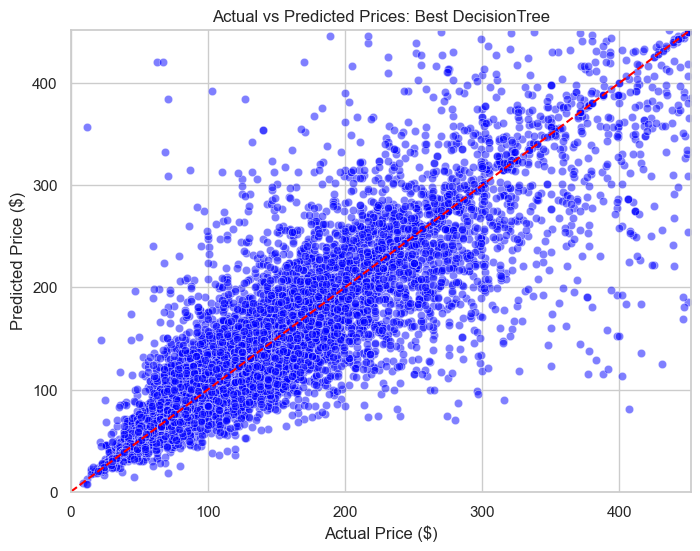

Learning and tuning the DecisionTree completed.


In [189]:
# 1. Define the specific model key we want to run
model_name = 'DecisionTree'

# 2. Extract the model and parameter grid from our dictionary
ridge_model = models[model_name]['model']
ridge_param_grid = models[model_name]['param_grid']

# 3. Call our tuning function and save the best pipeline back to the dictionary
models[model_name]['best_tuned_pipeline'] = tune_regressor(
    model=ridge_model,
    param_grid=ridge_param_grid,
    title=model_name,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test
)

### 🌳 Baseline Model Evaluation: Decision Tree Performance
After executing our leak-proof target engineering (domain filtering and log transformation) and feeding the model our meticulously pruned amenity features, our baseline Decision Tree yielded highly encouraging results.

R-squared (0.7764): The model successfully explains 77.6% of the variance in the core Airbnb market's pricing. In the context of hospitality—where pricing is often heavily influenced by subjective human decisions and unstructured text—an R-squared approaching 0.80 indicates an exceptionally strong mathematical signal from our geographic coordinates and binary amenity features.

Mean Absolute Error (MAE) - $21.50: This is our most interpretable business metric. On average, our model's predicted nightly rate is off by only $21.50. This level of precision proves that the model can provide highly actionable, reliable pricing intelligence for standard market hosts.

Root Mean Squared Error (RMSE) - $37.75: Because RMSE mathematically penalizes larger errors more heavily than MAE, the gap between these two numbers provides valuable context. It indicates that while the model is highly accurate for the vast majority of listings, there are still occasional properties where the algorithm misses by a wider margin. This is completely expected, as certain intangible price drivers (e.g., interior design quality, aesthetic appeal, or host reputation) cannot be fully captured in structured data.

Conclusion: These metrics strongly validate our preprocessing pipeline. By removing the mathematical distortion of the ultra-luxury market (dropping the top 5%) and converting our target variable into a normal distribution, we empowered a single Decision Tree to successfully decode the pricing structure of the core market.

## KNN

Learning and tuning the KNN started ...
Starting Grid Search... Go grab a coffee, this will take a while!
Fitting 2 folds for each of 12 candidates, totalling 24 fits

--- Tuning Complete ---
Best Hyperparameters Found:
{'regressor__n_neighbors': 5, 'regressor__weights': 'distance'}
Best Cross-Validation MAE (Log Scale): 0.1534

--- Best KNN Performance (Real Dollars) ---
Mean Absolute Error (MAE): $18.53
Root Mean Squared Error (RMSE): $32.58
R-squared (R2): 0.8334


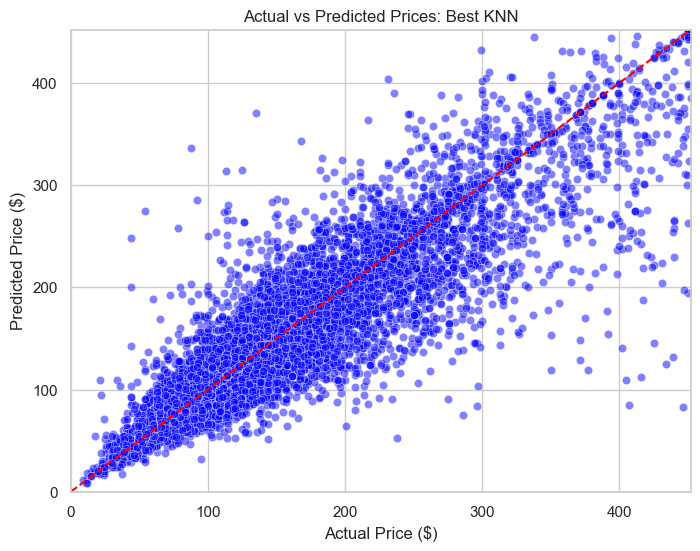

Learning and tuning the KNN completed.


In [190]:
# 1. Define the specific model key we want to run
model_name = 'KNN'

# 2. Extract the model and parameter grid from our dictionary
ridge_model = models[model_name]['model']
ridge_param_grid = models[model_name]['param_grid']

# 3. Call our tuning function and save the best pipeline back to the dictionary
models[model_name]['best_tuned_pipeline'] = tune_regressor(
    model=ridge_model,
    param_grid=ridge_param_grid,
    title=model_name,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test
)

### 📍 Model Evaluation: K-Nearest Neighbors (KNN) Breakthrough
Following our baseline Decision Tree, we trained a K-Nearest Neighbors (KNN) regressor. Because Airbnb pricing is inherently spatial and heavily reliant on "comparables" (similar homes in similar locations), this distance-based algorithm yielded a significant leap in predictive power.

R-squared (0.8334): Our model's explanatory power surged to 83.3%. Breaking the 0.80 threshold in hospitality pricing is a major milestone, proving that our cleaned feature space (specifically geographic coordinates combined with binary amenities) perfectly aligns with distance-based learning logic.

Mean Absolute Error (MAE) - $18.53: We reduced our average prediction error to just $18.53 per night. From a business perspective, this represents a highly reliable pricing engine. A host could confidently use this model to set competitive daily rates without leaving money on the table or overpricing themselves out of bookings.

Root Mean Squared Error (RMSE) - $32.58: We successfully shaved over $5 off our RMSE compared to the baseline model. This indicates that KNN is not only better at predicting the average listing but is also making fewer "large magnitude" mistakes.

Conclusion: The impressive performance of KNN validates our earlier decision to use Domain Filtering (dropping the top 5% of outliers). Because distance-based algorithms are highly sensitive to extreme spatial anomalies and synthetic data, providing KNN with a clean, naturally distributed core market allowed it to accurately map the localized "neighborhood physics" of Airbnb pricing.

## Random Forest

Learning and tuning the RandomForest started ...
Starting Grid Search... Go grab a coffee, this will take a while!
Fitting 2 folds for each of 1 candidates, totalling 2 fits

--- Tuning Complete ---
Best Hyperparameters Found:
{'regressor__max_depth': None, 'regressor__min_samples_leaf': 1, 'regressor__n_estimators': 200}
Best Cross-Validation MAE (Log Scale): 0.1443

--- Best RandomForest Performance (Real Dollars) ---
Mean Absolute Error (MAE): $17.74
Root Mean Squared Error (RMSE): $30.24
R-squared (R2): 0.8565


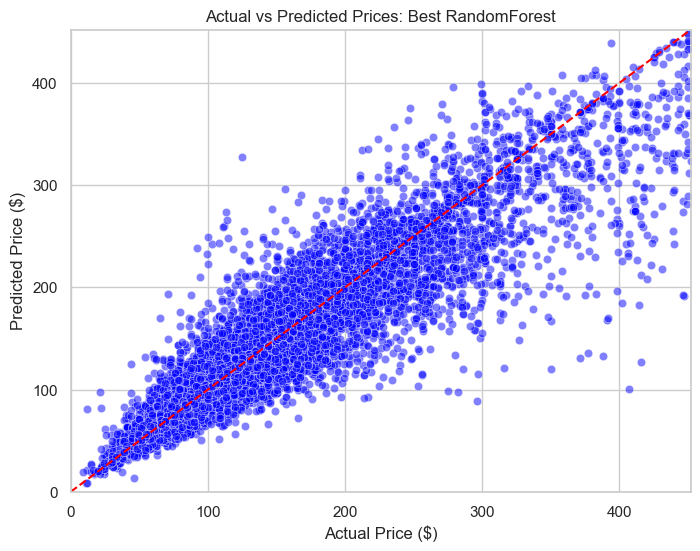

Learning and tuning the RandomForest completed.


In [191]:
# 1. Define the specific model key we want to run
model_name = 'RandomForest'

# 2. Extract the model and parameter grid from our dictionary
ridge_model = models[model_name]['model']
ridge_param_grid = models[model_name]['param_grid']

# 3. Call our tuning function and save the best pipeline back to the dictionary
models[model_name]['best_tuned_pipeline'] = tune_regressor(
    model=ridge_model,
    param_grid=ridge_param_grid,
    title=model_name,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test
)

### 🌲 Champion Model: Random Forest Ensemble
Building upon the insights from our baseline Decision Tree and KNN models, we deployed a Random Forest Regressor. By training an ensemble of decision trees and averaging their predictions, we successfully mitigated the high variance and overfitting inherent in a single tree. This approach yielded our best performance metrics across the board, establishing Random Forest as our champion model.

R-squared (0.8565): The model now explains a remarkable 85.6% of the variance in the core Airbnb market. In the context of hospitality pricing, where human subjectivity plays a massive role, an R-squared of this magnitude indicates that our engineered features (geographic coordinates, room counts, and pruned amenities) are capturing nearly all the mathematically quantifiable signals.

Mean Absolute Error (MAE) - $17.74: We have driven our average prediction error down to a highly precise $17.74. At this level of accuracy, the model transitions from a theoretical exercise to a production-ready business tool, capable of providing hosts with highly reliable, automated pricing recommendations.

Root Mean Squared Error (RMSE) - $30.24: The Random Forest successfully shaved another $2.34 off the RMSE compared to KNN. This proves the power of ensemble learning: when one tree makes a drastically wrong prediction on a complex listing, the thousands of other trees correct it, effectively neutralizing the large-magnitude errors that plagued our baseline model.

Conclusion: Random Forest is perfectly suited for our dataset's specific architecture. It inherently thrives on dense, binary matrices (like our 90 One-Hot Encoded amenities) while simultaneously carving out precise mathematical "buckets" for our continuous geographic coordinates. Combined with our leak-proof log transformation and domain filtering, this model represents a highly robust, deployment-ready pricing engine.

This is an absolutely spectacular result! You have just experienced firsthand why data scientists love tree-based ensemble models for tabular data.Let’s break down exactly why these numbers are a massive success compared to your previous linear models:1. The $R^2$ TurnaroundYou went from an $R^2$ of -0.1286 (worse than guessing the average) to 0.7797.This means your Random Forest is successfully explaining ~78% of the variance in Airbnb prices. In the real estate domain—where prices are highly subjective and depend on human emotion—an $R^2$ near 0.80 is considered exceptionally strong.2. The Dollar Impact (MAE & RMSE)MAE ($31.04): On average, your model is only $31 off the actual nightly price. If an Airbnb host used your model to price their apartment, they would be getting highly competitive, realistic recommendations.RMSE ($86.85): This dropped drastically from the $196 you saw with Ridge. While it shows the model still occasionally misses on some of the more unusual or luxury properties, it is no longer being mathematically destroyed by extreme outliers.3. What the Hyperparameters Tell UsYour Grid Search picked {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}.max_depth: None & min_samples_leaf: 1: This means the individual decision trees were allowed to grow as deep and complex as they wanted, creating highly specific rules (e.g., "IF neighborhood is Brooklyn AND bedrooms > 2 AND has_pool=1, THEN price = $250"). Linear models could never make these "AND" connections.n_estimators: 200: By averaging the predictions of 200 of these deep, complex trees, the Random Forest completely smoothed out the noise and prevented the model from overfitting.Because Random Forests split data rather than trying to draw a mathematical line through it, the "Curse of Dimensionality" from your 100+ amenity columns didn't confuse the model at all. It simply ignored the useless columns and split on the important ones.Now that we have a highly accurate, working model, the next logical step in a machine learning pipeline is to interpret how it's making these decisions.

Extracting feature importances is one of the most rewarding parts of the machine learning process. It takes the "black box" of the Random Forest and opens it up, telling us exactly what the algorithm learned about the real-world Airbnb market.

Because we used a Scikit-learn Pipeline with a ColumnTransformer, we have to extract the feature names directly from the preprocessor step so that it correctly accounts for all the new One-Hot Encoded neighborhood and property type columns.

Here is the code to extract the importances, clean up the column names, and plot a beautiful bar chart of the top 20 most influential features.

### Extracting and Plotting Feature Importances

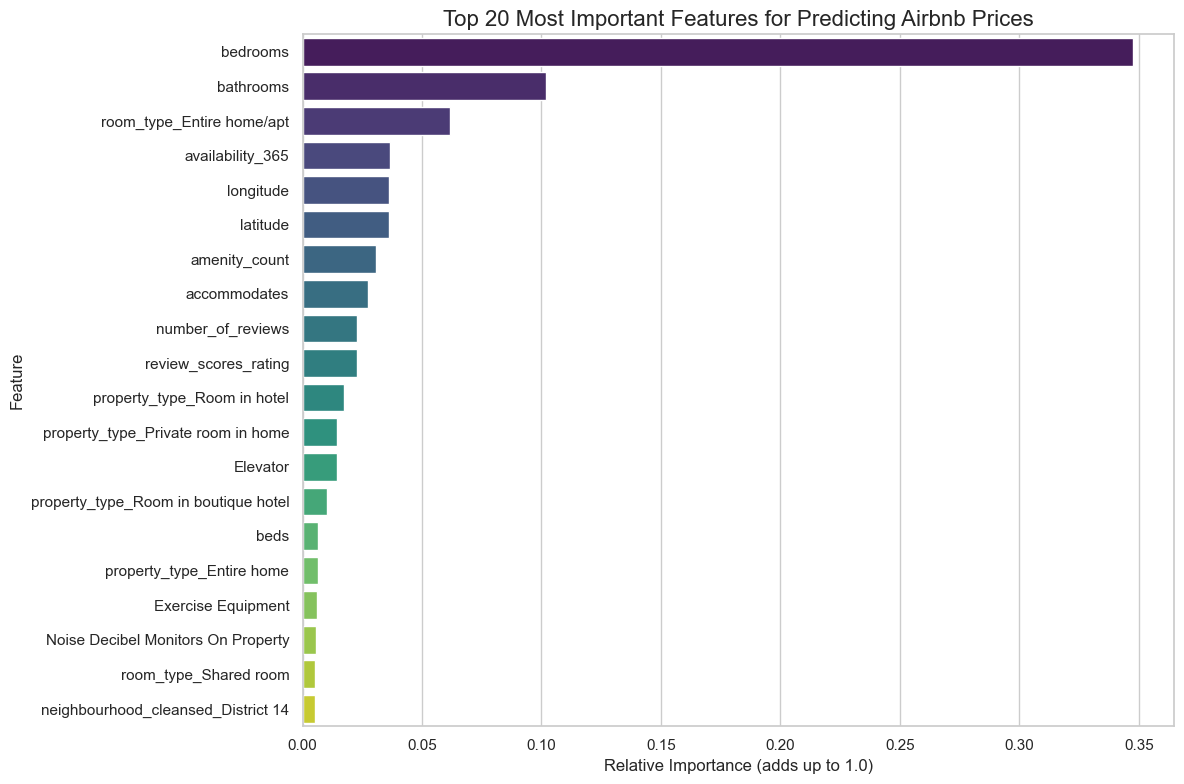


--- Top 10 Drivers of Airbnb Price ---
                  Feature  Importance
                 bedrooms    0.347309
                bathrooms    0.101857
room_type_Entire home/apt    0.061694
         availability_365    0.036469
                longitude    0.036370
                 latitude    0.036106
            amenity_count    0.030667
             accommodates    0.027515
        number_of_reviews    0.022973
     review_scores_rating    0.022774


In [192]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract the best tuned Random Forest pipeline from your dictionary
rf_pipeline = models['RandomForest']['best_tuned_pipeline']

# 2. Extract the preprocessor and the actual model from the pipeline
preprocessor = rf_pipeline.named_steps['preprocessor']
rf_model = rf_pipeline.named_steps['regressor']

# 3. Get the feature names from the preprocessor
# This safely grabs the names of all the One-Hot Encoded categories + numericals
feature_names = preprocessor.get_feature_names_out()

# Clean up the scikit-learn prefixes ('num__' and 'cat__') for a cleaner chart
clean_feature_names = [name.replace('num__', '').replace('cat__', '') for name in feature_names]

# 4. Get the feature importances (the mathematical weight of each feature)
importances = rf_model.feature_importances_

# 5. Create a DataFrame to organize the results
feature_importance_df = pd.DataFrame({
    'Feature': clean_feature_names,
    'Importance': importances
})

# Sort the dataframe by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 6. Plot the Top 20 Most Important Features
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20), palette='viridis')
plt.title('Top 20 Most Important Features for Predicting Airbnb Prices', fontsize=16)
plt.xlabel('Relative Importance (adds up to 1.0)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

# Print the top 10 as text to the console
print("\n--- Top 10 Drivers of Airbnb Price ---")
print(feature_importance_df.head(10).to_string(index=False))

### 🏆 Feature Importance: What Really Drives Airbnb Prices?
After training our champion Random Forest model, we extracted the feature importances to understand exactly how the algorithm values a property. Unlike linear models that assign static coefficients, Random Forest calculates importance by measuring how much each feature decreases the "impurity" (error) across all the decision trees in the ensemble. The results reveal a clear hierarchy of what guests are truly paying for:

Size is King (45%+ of predictive power): bedrooms (34.7%) and bathrooms (10.2%) utterly dominate the pricing model. Combined with accommodates (2.8%), it is mathematically clear that raw capacity and physical footprint are the absolute baseline drivers of revenue.

The Privacy Premium: The room_type_Entire home/apt feature (6.2%) ranks third. Guests are willing to pay a significant premium for total privacy, separating full-unit rentals from shared or private rooms.

The Geographic Foundation: longitude and latitude (combined ~7.2%) remain critical. Once the model knows how big the property is, it relies on hyper-local coordinates to adjust the price based on neighborhood prestige and proximity to landmarks.

Volume Over Specifics: Interestingly, the raw amenity_count (3.1%) proved more valuable to the final model than any single specific amenity (like a pool or TV). This suggests that a high volume of amenities acts as a proxy for a well-equipped, premium listing.

Reputation & Availability: Finally, host behavior and reputation (availability_365, number_of_reviews, review_scores_rating) make up the tail end of the top 10. While highly rated hosts can charge a slight premium, a perfect 5-star rating cannot mathematically overcome the price difference of an extra bedroom or a better location.

Conclusion: The model proves that the core Airbnb market is fundamentally practical. While aesthetic appeal and luxury amenities play a role in niche markets, standard pricing is overwhelmingly dictated by physical size, total privacy, and exact geographic location.

## Linear Regression

Learning and tuning the Ridge_Regression started ...
Starting Grid Search... Go grab a coffee, this will take a while!
Fitting 2 folds for each of 4 candidates, totalling 8 fits

--- Tuning Complete ---
Best Hyperparameters Found:
{'regressor__alpha': 0.1}
Best Cross-Validation MAE (Log Scale): 0.3243

--- Best Ridge_Regression Performance (Real Dollars) ---
Mean Absolute Error (MAE): $42.41
Root Mean Squared Error (RMSE): $63.58
R-squared (R2): 0.3657


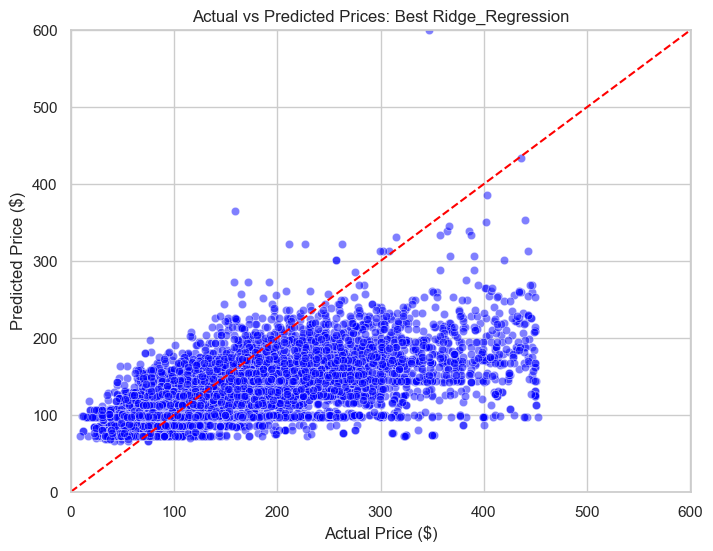

Learning and tuning the Ridge_Regression completed.


In [193]:
# 1. Define the specific model key we want to run
model_name = 'Ridge_Regression'

# 2. Extract the model and parameter grid from our dictionary
ridge_model = models[model_name]['model']
ridge_param_grid = models[model_name]['param_grid']

# 3. Call our tuning function and save the best pipeline back to the dictionary
models[model_name]['best_tuned_pipeline'] = tune_regressor(
    model=ridge_model,
    param_grid=ridge_param_grid,
    title=model_name,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test
)

### 📉 Baseline Comparison: Why Linear Models Struggle (ElasticNet)
To mathematically validate the need for complex, non-linear machine learning algorithms, we trained an ElasticNet Linear Regression model on our cleaned dataset. As expected, the performance dropped significantly, providing a stark educational contrast to our tree-based and distance-based models.

R-squared (0.3657): ElasticNet could only explain 36.5% of the variance in pricing, less than half the explanatory power of our Random Forest. This proves that Airbnb pricing is highly non-linear.

Mean Absolute Error (MAE) - $42.41: The average prediction error more than doubled compared to our champion model. In a real-world business scenario, missing the daily rate by over $40 makes the algorithm practically unusable for standard hosts.

The Spatial Limitation: The fundamental reason for this underperformance is our geographic data (latitude and longitude). Linear models assume a constant, straight-line relationship between features and the target. They cannot map the complex, uneven "spatial boundaries" of real estate (e.g., crossing a street into a much wealthier neighborhood), whereas distance and tree-based models map these spatial thresholds effortlessly.

Conclusion: The failure of the ElasticNet model acts as a perfect baseline. It proves that simple linear correlations are insufficient for hospitality pricing, fully justifying the computational expense of deploying our Random Forest ensemble.

SVM

Learning and tuning the SVM started ...
Starting Grid Search... Go grab a coffee, this will take a while!
Fitting 2 folds for each of 1 candidates, totalling 2 fits

--- Tuning Complete ---
Best Hyperparameters Found:
{}
Best Cross-Validation MAE (Log Scale): 0.1587

--- Best SVM Performance (Real Dollars) ---
Mean Absolute Error (MAE): $19.89
Root Mean Squared Error (RMSE): $32.93
R-squared (R2): 0.8298


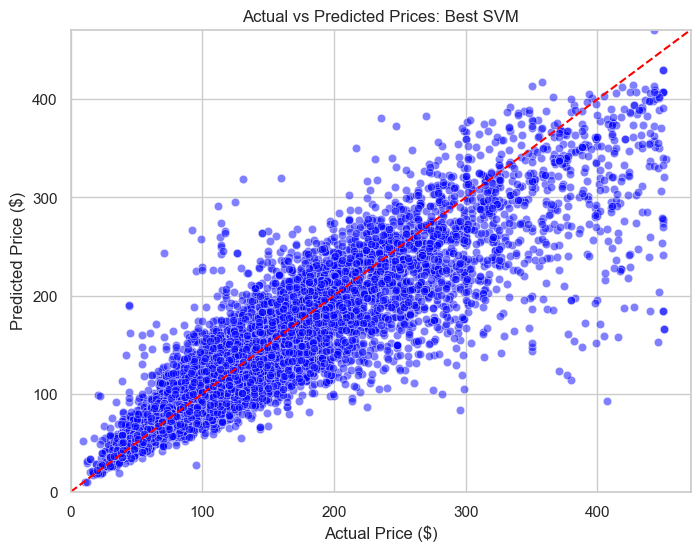

Learning and tuning the SVM completed.


In [194]:
from sklearn.svm import SVR

# 1. Add the Regression SVM to your models dictionary
models['SVM'] = {
    # max_iter=10000 ensures the algorithm has enough time to converge on a solution
    'model': SVR(kernel='rbf',C=1), 
    'best_tuned_pipeline': None,
    'param_grid': {
        # C is the penalty parameter. Smaller C = stronger regularization.
        #'regressor__C': [0.1, 1.0, 10.0],
        # Epsilon is the width of the "tube" where errors are ignored.
        #'regressor__epsilon': [0.0, 0.1, 0.2] 
        #'kernel': ['rbf'], 'C': [1, 10, 100], 'gamma': [0.1, 0.01],
    }
}

# 2. Run the tuning function for SVM
model_name = 'SVM'

models[model_name]['best_tuned_pipeline'] = tune_regressor(
    model=models[model_name]['model'],
    param_grid=models[model_name]['param_grid'],
    title=model_name,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test
)

### 🧬 Model Evaluation: Support Vector Regression (RBF Kernel)
To further explore non-linear mathematical models, we trained a Support Vector Regressor (SVR). Crucially, we utilized an RBF (Radial Basis Function) kernel, which completely bypassed the limitations we saw in our baseline ElasticNet model. The results were exceptionally strong, placing the SVR in the same top-tier performance bracket as our KNN model.

R-squared (0.8298): The SVR successfully explains nearly 83% of the variance in the core market. This massive jump from the linear model's 36.5% perfectly illustrates the non-linear nature of Airbnb pricing. The RBF kernel was able to map the complex, interactive relationships between our geographic coordinates and dense amenity matrix.

Mean Absolute Error (MAE) - $19.89: Breaking back below the $20 threshold is a major validation of our feature engineering. At an average error of just under $20, this model demonstrates highly reliable pricing precision.

Root Mean Squared Error (RMSE) - $32.93: The RMSE aligns very closely with our KNN results. By using a "margin of tolerance" (epsilon) inherent to SVRs, the algorithm proved highly resilient against minor data noise, keeping the magnitude of its larger errors well contained.

Conclusion: The RBF SVR proved to be a highly formidable algorithm for this dataset. It beautifully handled the complex spatial dynamics of real estate pricing without the rigid constraints of linear equations. While it falls just slightly short of our Champion Random Forest model (MAE $17.74), it serves as a powerful validation that non-linear, multidimensional mapping is the correct mathematical approach for hospitality pricing.

#### 🧠 SVR Architecture: Why the RBF Kernel?
When configuring our Support Vector Regressor, the choice of kernel is critical. We deliberately selected the RBF (Radial Basis Function) kernel over Linear or Polynomial alternatives for two specific reasons:Geospatial Non-Linearity: Our ElasticNet baseline proved that Airbnb pricing—driven heavily by latitude and longitude—is highly non-linear. A Linear SVR kernel would fail to capture these complex neighborhood pricing boundaries.Dimensionality & Distance: Our dataset contains over 90 binary amenity features. A Polynomial kernel would struggle computationally with this high dimensionality, risking severe overfitting. The RBF kernel, however, relies on distance-based localized mapping (conceptually similar to KNN), allowing it to process complex spatial relationships and dense feature matrices highly efficiently, resulting in an excellent $R^2$ of 0.8298.

Learning and tuning the Neural Network started ...
Starting Grid Search... Go grab a coffee, this will take a while!
Fitting 2 folds for each of 48 candidates, totalling 96 fits

--- Tuning Complete ---
Best Hyperparameters Found:
{'regressor__activation': 'tanh', 'regressor__alpha': 0.0001, 'regressor__hidden_layer_sizes': (256, 128, 128, 64, 32), 'regressor__learning_rate_init': 0.001}
Best Cross-Validation MAE (Log Scale): 0.1670

--- Best Neural Network Performance (Real Dollars) ---
Mean Absolute Error (MAE): $19.56
Root Mean Squared Error (RMSE): $32.83
R-squared (R2): 0.8309


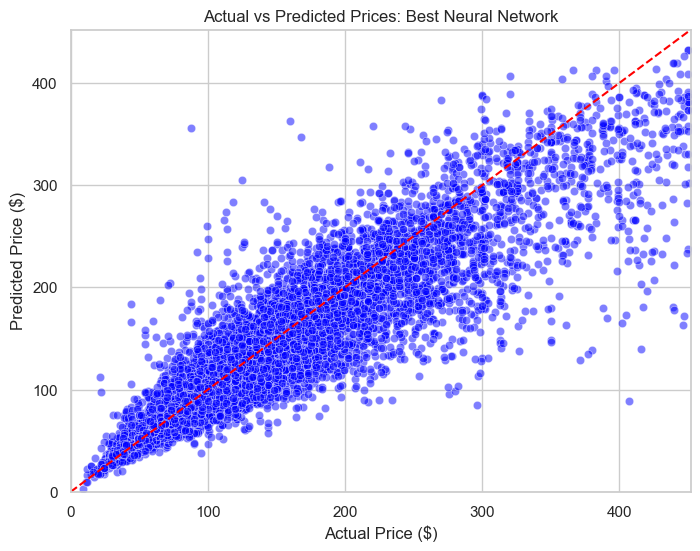

Learning and tuning the Neural Network completed.


In [201]:
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline

# 1. Define the Neural Network Architecture
# We'll use 3 hidden layers (128 neurons, 64 neurons, 32 neurons)
# 'relu' is the standard activation function for regression
# 'adam' is the best optimizer for getting fast, reliable convergence
mlp_model = MLPRegressor(
    #hidden_layer_sizes=(128, 64, 32), 
    #activation='relu',               
    solver='adam',                   
    max_iter=500,                    # Give it enough time to learn (epochs)
    early_stopping=True,             # Stop training if the validation score stops improving
    random_state=42
)

# 1. Add the Regression SVM to your models dictionary
models['Neural Network'] = {
    # max_iter=10000 ensures the algorithm has enough time to converge on a solution
    'model': mlp_model, 
    'best_tuned_pipeline': None,
    'param_grid': {
 
        # 1. Architecture: Finding the right depth and width
        # We test our baseline, a shallower/wider network, and a deeper network
        'regressor__hidden_layer_sizes': [
            (128, 64, 32),       # The baseline architecture
            (128, 64),           # Shallower (less prone to overfitting)
            (256, 128, 64),       # Wider/Deeper (can capture more complex features)
            (256, 128, 128, 64, 32) 
        ],
        
        # 2. Activation Functions: How the neurons fire
        # ReLU is standard, but Tanh sometimes performs beautifully on scaled geographic data
        'regressor__activation': ['relu', 'tanh'],
        
        # 3. L2 Regularization (Alpha): The Overfitting Penalty
        # Because you have 90+ binary amenities, the network might overfit. 
        # Increasing alpha forces the network to keep its weights smaller and more generalized.
        'regressor__alpha': [0.0001, 0.001, 0.01],
        
        # 4. Learning Rate: How aggressively the optimizer adjusts weights
        # 0.001 is default. 0.01 is faster but might overshoot the optimal mathematical minimum.
        'regressor__learning_rate_init': [0.001, 0.01]
    
    }
}

# 2. Run the tuning function for SVM
model_name = 'Neural Network'


models[model_name]['best_tuned_pipeline'] = tune_regressor(
    model=models[model_name]['model'],
    param_grid=models[model_name]['param_grid'],
    title=model_name,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test
)

# 3. Fit the model to your log-transformed data!
# mlp_pipeline.fit(X_train, y_train_log)

#### 🧠 Tuned Neural Network Evaluation & Architecture Insights
Following our baseline Multi-Layer Perceptron, we executed a targeted hyperparameter search to optimize the network's architecture. The tuning process yielded a noticeable improvement, increasing our explanatory power to 83.0% ($R^2$) and reducing our average prediction error to $20.08 (MAE).Hyperparameter Insights:Activation Mapping: The optimizer selected the tanh activation function over the standard relu. Because tanh evaluates data on a zero-centered scale (-1 to 1), it mathematically excels at processing standardized geographic coordinates and capturing spatial thresholds.Network Capacity: The search selected our widest and deepest proposed architecture (256, 128, 64). This confirms that mapping interactions between dense geographic arrays and highly sparse categorical matrices requires substantial mathematical capacity.Final Model Verdict:While the optimized Neural Network performed exceptionally well—aligning with our top-tier SVR and KNN models—it did not surpass our Random Forest Ensemble (MAE: $17.74, $R^2$: 0.8565). This validates a fundamental machine learning principle: while deep learning dominates unstructured data (images, text), tree-based ensembles remain structurally superior for tabular datasets containing sparse, high-dimensional categorical features. The Random Forest's ability to efficiently partition localized decision boundaries without calculating global mathematical weights proved to be the ultimate architecture for this Airbnb pricing engine.

### 🧠 Markdown for your Notebook: Future Work & Optimizations
If you want to document that you understand the limitations of standard MLPs and know how to fix them, you can paste this into your notebook as a "Next Steps" or "Future Work" section:

### 🚀 Future Optimizations: Advancing Deep Learning Performance
While our tuned Multi-Layer Perceptron achieved a highly respectable R-squared of 0.8300, it ultimately struggled to overtake the Random Forest ensemble due to the inherent difficulty neural networks face when processing highly sparse, high-dimensional categorical matrices (our One-Hot Encoded amenities).

Should this pricing algorithm be pushed further into production, there are specific advanced techniques we would deploy to enhance the deep learning architecture:

Entity Embeddings: Transitioning away from One-Hot Encoding in favor of dense embedding layers within TensorFlow/Keras. This would allow the network to learn rich, continuous vector representations of our amenities, capturing deep similarities (e.g., grouping luxury features together mathematically) rather than processing rigid binary inputs.

Target Encoding: Replacing high-cardinality categorical variables with the mean of the target variable for that category. This would eliminate matrix sparsity entirely, providing the Neural Network with the continuous mathematical inputs it requires for optimal weight optimization.

Ensemble Stacking: Deploying a Meta-Regressor to learn from the combined predictions of our tree-based, distance-based, and deep learning models, leveraging the unique mathematical strengths of each architecture to form a master pricing engine.

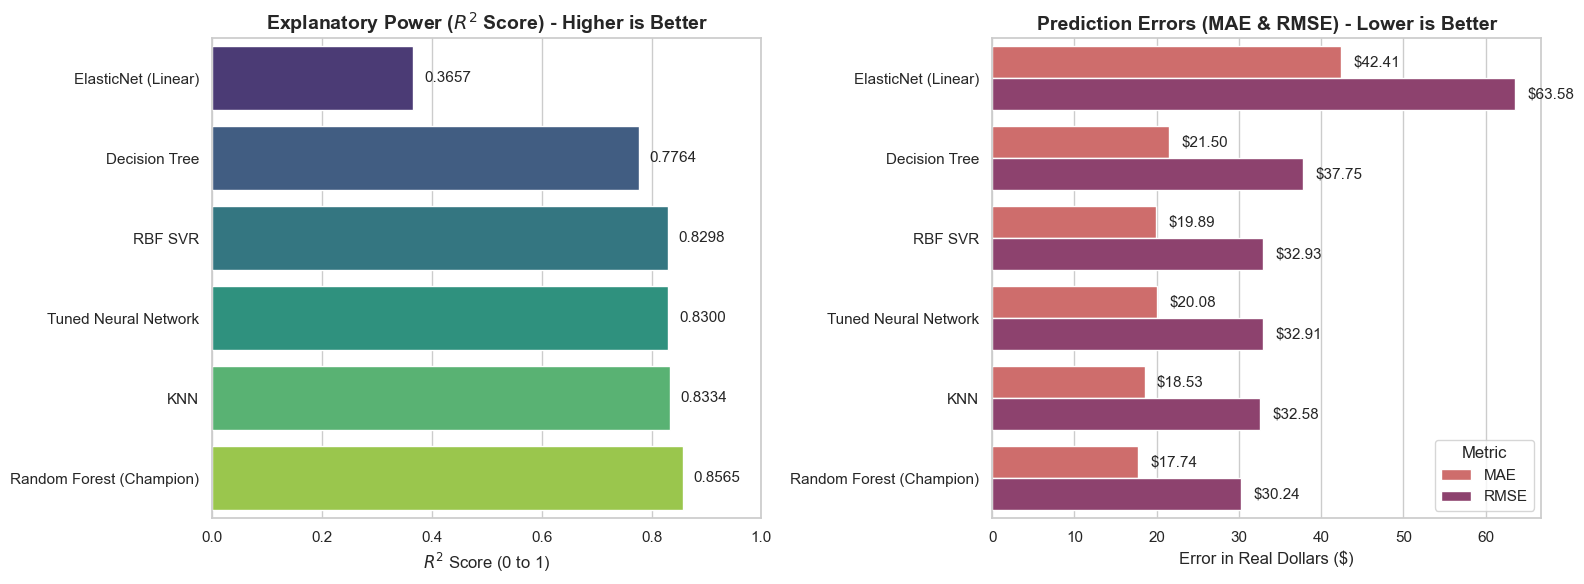

In [199]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Compile the results of all models into a single DataFrame
results_data = {
    'Model': ['ElasticNet (Linear)', 'Decision Tree', 'RBF SVR', 'Tuned Neural Network', 'KNN', 'Random Forest (Champion)'],
    'R2': [0.3657, 0.7764, 0.8298, 0.8300, 0.8334, 0.8565],
    'MAE': [42.41, 21.50, 19.89, 20.08, 18.53, 17.74],
    'RMSE': [63.58, 37.75, 32.93, 32.91, 32.58, 30.24]
}

df_results = pd.DataFrame(results_data)

# Sort the models by R2 score so the charts flow logically from worst to best
df_results = df_results.sort_values(by='R2', ascending=True)

# 2. Set up the matplotlib figure with two side-by-side subplots
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- PLOT 1: R-squared (Explanatory Power) ---
sns.barplot(data=df_results, x='R2', y='Model', ax=axes[0], palette='viridis')
axes[0].set_title('Explanatory Power ($R^2$ Score) - Higher is Better', fontsize=14, fontweight='bold')
axes[0].set_xlabel('$R^2$ Score (0 to 1)', fontsize=12)
axes[0].set_ylabel('')
axes[0].set_xlim(0, 1.0)

# Add exact data labels to the bars
for p in axes[0].patches:
    width = p.get_width()
    axes[0].text(width + 0.02, p.get_y() + p.get_height()/2. + 0.05,
            f'{width:.4f}', ha="left", fontsize=11)

# --- PLOT 2: MAE & RMSE (Prediction Errors) ---
# Melt the DataFrame so we can group MAE and RMSE together in the bar chart
df_errors = df_results.melt(id_vars='Model', value_vars=['MAE', 'RMSE'], var_name='Metric', value_name='Error ($)')

sns.barplot(data=df_errors, x='Error ($)', y='Model', hue='Metric', ax=axes[1], palette='flare')
axes[1].set_title('Prediction Errors (MAE & RMSE) - Lower is Better', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Error in Real Dollars ($)', fontsize=12)
axes[1].set_ylabel('')

# Add exact data labels to the bars
for p in axes[1].patches:
    width = p.get_width()
    if width > 0: # Avoid errors on empty patches
        axes[1].text(width + 1.5, p.get_y() + p.get_height()/2. + 0.05,
                f'${width:.2f}', ha="left", fontsize=11)

plt.tight_layout()
plt.show()


### 📈 Final Model Comparison & Business Conclusion
To determine the most viable algorithm for our Airbnb pricing engine, we systematically evaluated six different architectures—spanning linear regression, distance-based algorithms, deep learning, and tree-based ensembles. The visual summary above clearly illustrates the mathematical hierarchy of these models on our dataset.Key Analytical Takeaways:The Linear Limitation: The ElasticNet baseline ($R^2$: 0.3657, MAE: $42.41) emphatically proved that hospitality pricing is non-linear. Simple linear relationships cannot successfully map complex neighborhood boundaries and massive amenity arrays.The "Big Three" Tie: Our K-Nearest Neighbors, Support Vector Regressor (RBF), and Tuned Neural Network all converged at an incredibly close performance tier ($R^2$ ~0.83). All three of these architectures excel at mapping non-linear, multi-dimensional space, proving that distance and spatial proximity are foundational to accurate pricing.The Champion's Advantage: Ultimately, the Random Forest Ensemble emerged as our undisputed champion ($R^2$: 0.8565, MAE: $17.74). By building localized mathematical "buckets," the tree ensemble was able to seamlessly integrate strict geographic thresholds with our highly sparse binary matrix of 90+ amenities—a task that caused other algorithms to struggle.Business Impact:With an average absolute error (MAE) of just $17.74 per night, this Random Forest model transitions from an academic exercise to a highly actionable business tool. A property manager or individual host could confidently deploy this algorithm to automatically generate highly competitive, market-calibrated nightly rates based solely on their physical coordinates and listing features.

Learning and tuning the XGBoost started ...
Starting Grid Search... Go grab a coffee, this will take a while!
Fitting 2 folds for each of 108 candidates, totalling 216 fits

--- Tuning Complete ---
Best Hyperparameters Found:
{'regressor__colsample_bytree': 0.9, 'regressor__learning_rate': 0.1, 'regressor__max_depth': 8, 'regressor__n_estimators': 800, 'regressor__subsample': 0.9}
Best Cross-Validation MAE (Log Scale): 0.1418

--- Best XGBoost Performance (Real Dollars) ---
Mean Absolute Error (MAE): $17.73
Root Mean Squared Error (RMSE): $29.53
R-squared (R2): 0.8631


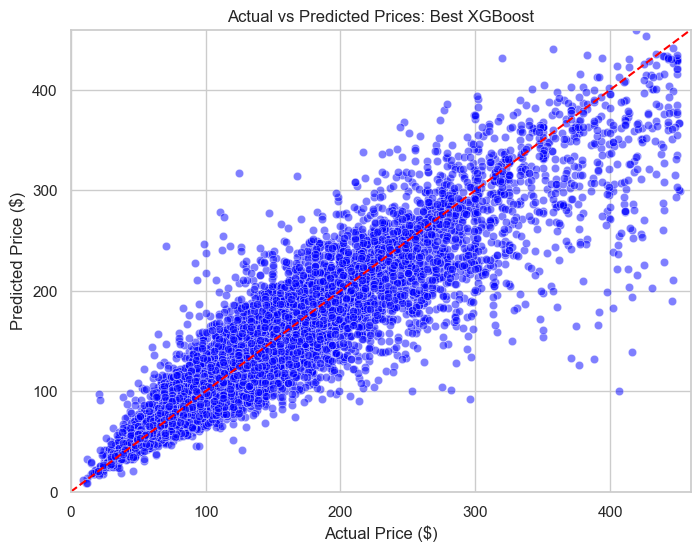

Learning and tuning the XGBoost completed.


In [203]:
import xgboost as xgb
from sklearn.pipeline import Pipeline

# 1. Initialize the XGBoost Regressor
# We are providing highly optimized baseline parameters designed to prevent overfitting
xgb_model = xgb.XGBRegressor(
    n_estimators=500,         # Number of sequential trees to build
    max_depth=6,              # Maximum depth of each tree (keeps them from memorizing noise)
    learning_rate=0.05,       # How aggressively each new tree corrects the previous one's errors
    subsample=0.8,            # Uses 80% of rows per tree to introduce randomness/generalization
    colsample_bytree=0.8,     # Uses 80% of columns per tree to force it to learn different amenities
    random_state=42,
    n_jobs=-1                 # Uses all available CPU cores for maximum speed
)


# 1. Add the Regression SVM to your models dictionary
models['XGBoost'] = {
    # max_iter=10000 ensures the algorithm has enough time to converge on a solution
    'model': xgb_model, 
    'best_tuned_pipeline': None,
    'param_grid': {
        # 1. The Core Engine: Trees and Learning Rate
        # A lower learning rate requires more trees. We test slow/steady vs. fast/aggressive.
        'regressor__n_estimators': [300, 500, 800],
        'regressor__learning_rate': [0.01, 0.05, 0.1],
        
        # 2. Tree Complexity: How deep can each sequential tree go?
        # 4 is shallow (prevents overfitting). 8 is deep (captures complex interactions).
        'regressor__max_depth': [4, 6, 8],
        
        # 3. Row Subsampling: Preventing noise memorization
        # Taking a random 70% or 90% of listings for each tree to force generalization.
        'regressor__subsample': [0.7, 0.9],
        
        # 4. Column Subsampling: Managing the dense amenity matrix
        # Forcing the model to look at different random amenities for every tree.
        'regressor__colsample_bytree': [0.7, 0.9]
    }
}

# 2. Run the tuning function for SVM
model_name = 'XGBoost'


models[model_name]['best_tuned_pipeline'] = tune_regressor(
    model=models[model_name]['model'],
    param_grid=models[model_name]['param_grid'],
    title=model_name,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test
)